# Code for Figure 4 and corresponding supplementary figures

In [1]:
import importlib 
import util, models, training

importlib.reload(util)
importlib.reload(models)
importlib.reload(training)

<module 'training' from '/home/unix/hschluet/projects/prt-pbmc/training.py'>

In [2]:
from data import PlateDataset
from util import torch_random_choice
from models import GatedAttentionMulti, GatedAttention

import torch
import numpy as np
import pandas as pd
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
import torchvision.transforms as T 
import seaborn as sns
import umap
import seaborn as sns 
from scipy import stats
from sklearn.metrics import roc_curve


device = 'cuda:0'

## Trajectories

In [3]:
res = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_scores.csv', index_col=0)[['patient', 'time', 'score']]
res['score'] = res['score'].clip(upper=1)  # cap similarity-to-healthy at 1; >1 arises from plate noise / small held-out healthy sample
res = res[res['time'] > 0].pivot(index='patient', columns='time', values='score')
res

time,1,2,3,4,5
patient,,,,,
P100,0.094033,0.158504,0.962617,0.895098,0.670133
P102,0.047206,0.112105,0.819053,0.122459,NaN
P103,0.014500,0.343160,0.080993,NaN,NaN
P104,0.073698,0.327489,0.022326,0.208230,0.112608
P105,0.262559,1.000000,1.000000,0.079315,0.400967
...,...,...,...,...,...
P95,0.138851,0.023804,0.284037,0.917144,0.719586
P96,0.010957,0.013574,0.019607,0.632630,0.679810
P97,0.002366,0.006680,0.012135,0.166456,0.061242


In [4]:
traj = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_trajectory_classes.csv', index_col='patient')
groups = pd.read_csv('meta/patient_diagnosis_groups.csv')
pat_info = groups.merge(traj, on='patient', how='left').set_index('patient')
pat_info

,group,trajectory
patient,,
P11,Sarcoma-Rhabdomyosarcoma,NaN
P12,H&N cancer,NaN
P13,Lymphoma,low
P14,H&N cancer,low
P15,CNS-Glioma,low
...,...,...
H46,healthy,NaN
H47,healthy,NaN
H48,healthy,NaN


### Fig. 4b

In [5]:
counts = pd.DataFrame()
# P39, P64 and P156 were irradiated alongside the meningioma cohort but have benign
# tumours (schwannoma, paraganglioma), so they carry no cancer-type group -> 'Other'
counts['counts'] = pat_info.fillna({'group': 'Other'}).groupby('group')['trajectory'].value_counts()
counts = counts.reset_index().pivot(index='group', columns='trajectory', values='counts').fillna(0).astype(int)
counts.loc[['H&N cancer', 'Chordoma/Chondrosarcoma', 'CNS-Meningioma', 'CNS-Glioma',
        'CNS-Ependymoma', 'CNS-Medulloblastoma',
       'Lymphoma', 'CNS-other', 'Other'], ['low', 'up', 'high']]


trajectory,low,up,high
group,,,
H&N cancer,10,14,4
Chordoma/Chondrosarcoma,8,5,4
CNS-Meningioma,5,6,4
CNS-Glioma,7,2,0
CNS-Ependymoma,4,2,0
CNS-Medulloblastoma,2,1,1
Lymphoma,3,0,1
CNS-other,5,6,0
Other,0,3,0


### Fig. 4c

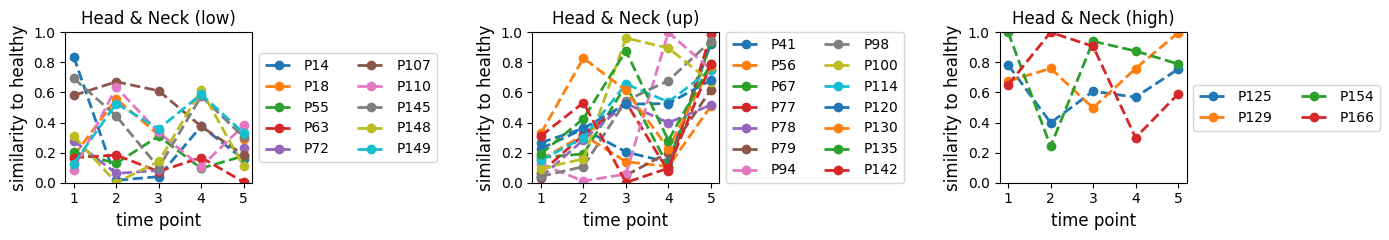

In [6]:
import matplotlib.pyplot as plt 

traj_groups = [pat_info[pat_info['trajectory'] == 'low'].index.values, 
               pat_info[pat_info['trajectory'] == 'up'].index.values, 
               pat_info[pat_info['trajectory'] == 'high'].index.values]
fig, axs = plt.subplots(1, 3, figsize=(14, 2.5))

for j, group in enumerate(traj_groups):
    pats = groups[groups['group'] == 'H&N cancer']['patient'].values
    pats = pats[np.isin(pats, group)]
    for p in pats:
        pres = res.loc[p]
        axs[j].plot(pres.index, pres.values, 'o--', lw=2, label=p)
    axs[j].legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2)
    axs[j].set_ylabel('similarity to healthy', size=12)
    axs[j].set_xlabel('time point', size=12)
    axs[j].set_xticks([1, 2, 3, 4, 5])
    axs[j].set_ylim(0, 1)

axs[0].set_title('Head & Neck (low)')
axs[1].set_title('Head & Neck (up)')
axs[2].set_title('Head & Neck (high)')
fig.tight_layout()
fig.subplots_adjust(wspace=1.5)

### Fig. 4a

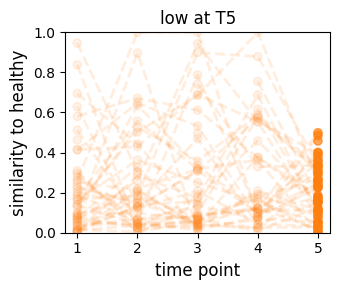

In [7]:
pats = pat_info[pat_info['trajectory'] == 'low'].index.values
colors = np.array([(1.0, 0.4980392156862745, 0.054901960784313725, 0.1)] * 4 + [(1.0, 0.4980392156862745, 0.054901960784313725, 0.7)])

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
for p in pats:
    pres = res.loc[p]
    ax.plot(pres.index, pres.values, '--', lw=2, color='#ff7f0e22')
    ax.scatter(pres.index, pres.values, marker='o', color=colors)
ax.set_title('low at T5')
ax.set_ylabel('similarity to healthy', size=12)
ax.set_xlabel('time point', size=12)
ax.set_ylim(0, 1)
fig.tight_layout()

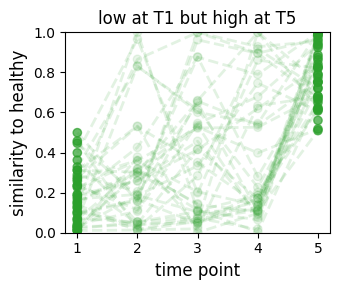

In [8]:
pats = pat_info[pat_info['trajectory'] == 'up'].index.values
colors = np.array([(0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 0.7)] + 
                  [(0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 0.1)] * 3 + 
                  [(0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 0.7)])

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
for p in pats:
    pres = res.loc[p]
    ax.plot(pres.index, pres.values, '--', lw=2, color='#2ca02c22')
    ax.scatter(pres.index, pres.values, marker='o', color=colors)
ax.set_title('low at T1 but high at T5')
ax.set_ylabel('similarity to healthy', size=12)
ax.set_xlabel('time point', size=12)
ax.set_ylim(0, 1)
fig.tight_layout()

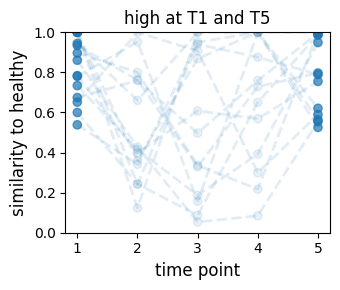

In [9]:
pats = pat_info[pat_info['trajectory'] == 'high'].index.values
colors = np.array([(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 0.7)] + 
                  [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 0.1)] * 3 + 
                  [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 0.7)])

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
for p in pats:
    pres = res.loc[p]
    ax.plot(pres.index, pres.values, '--', lw=2, color='#1f77b422')
    ax.scatter(pres.index, pres.values, marker='o', color=colors)
ax.set_title('high at T1 and T5')
ax.set_ylabel('similarity to healthy', size=12)
ax.set_xlabel('time point', size=12)
ax.set_ylim(0, 1)
fig.tight_layout()

### Fig. S4a

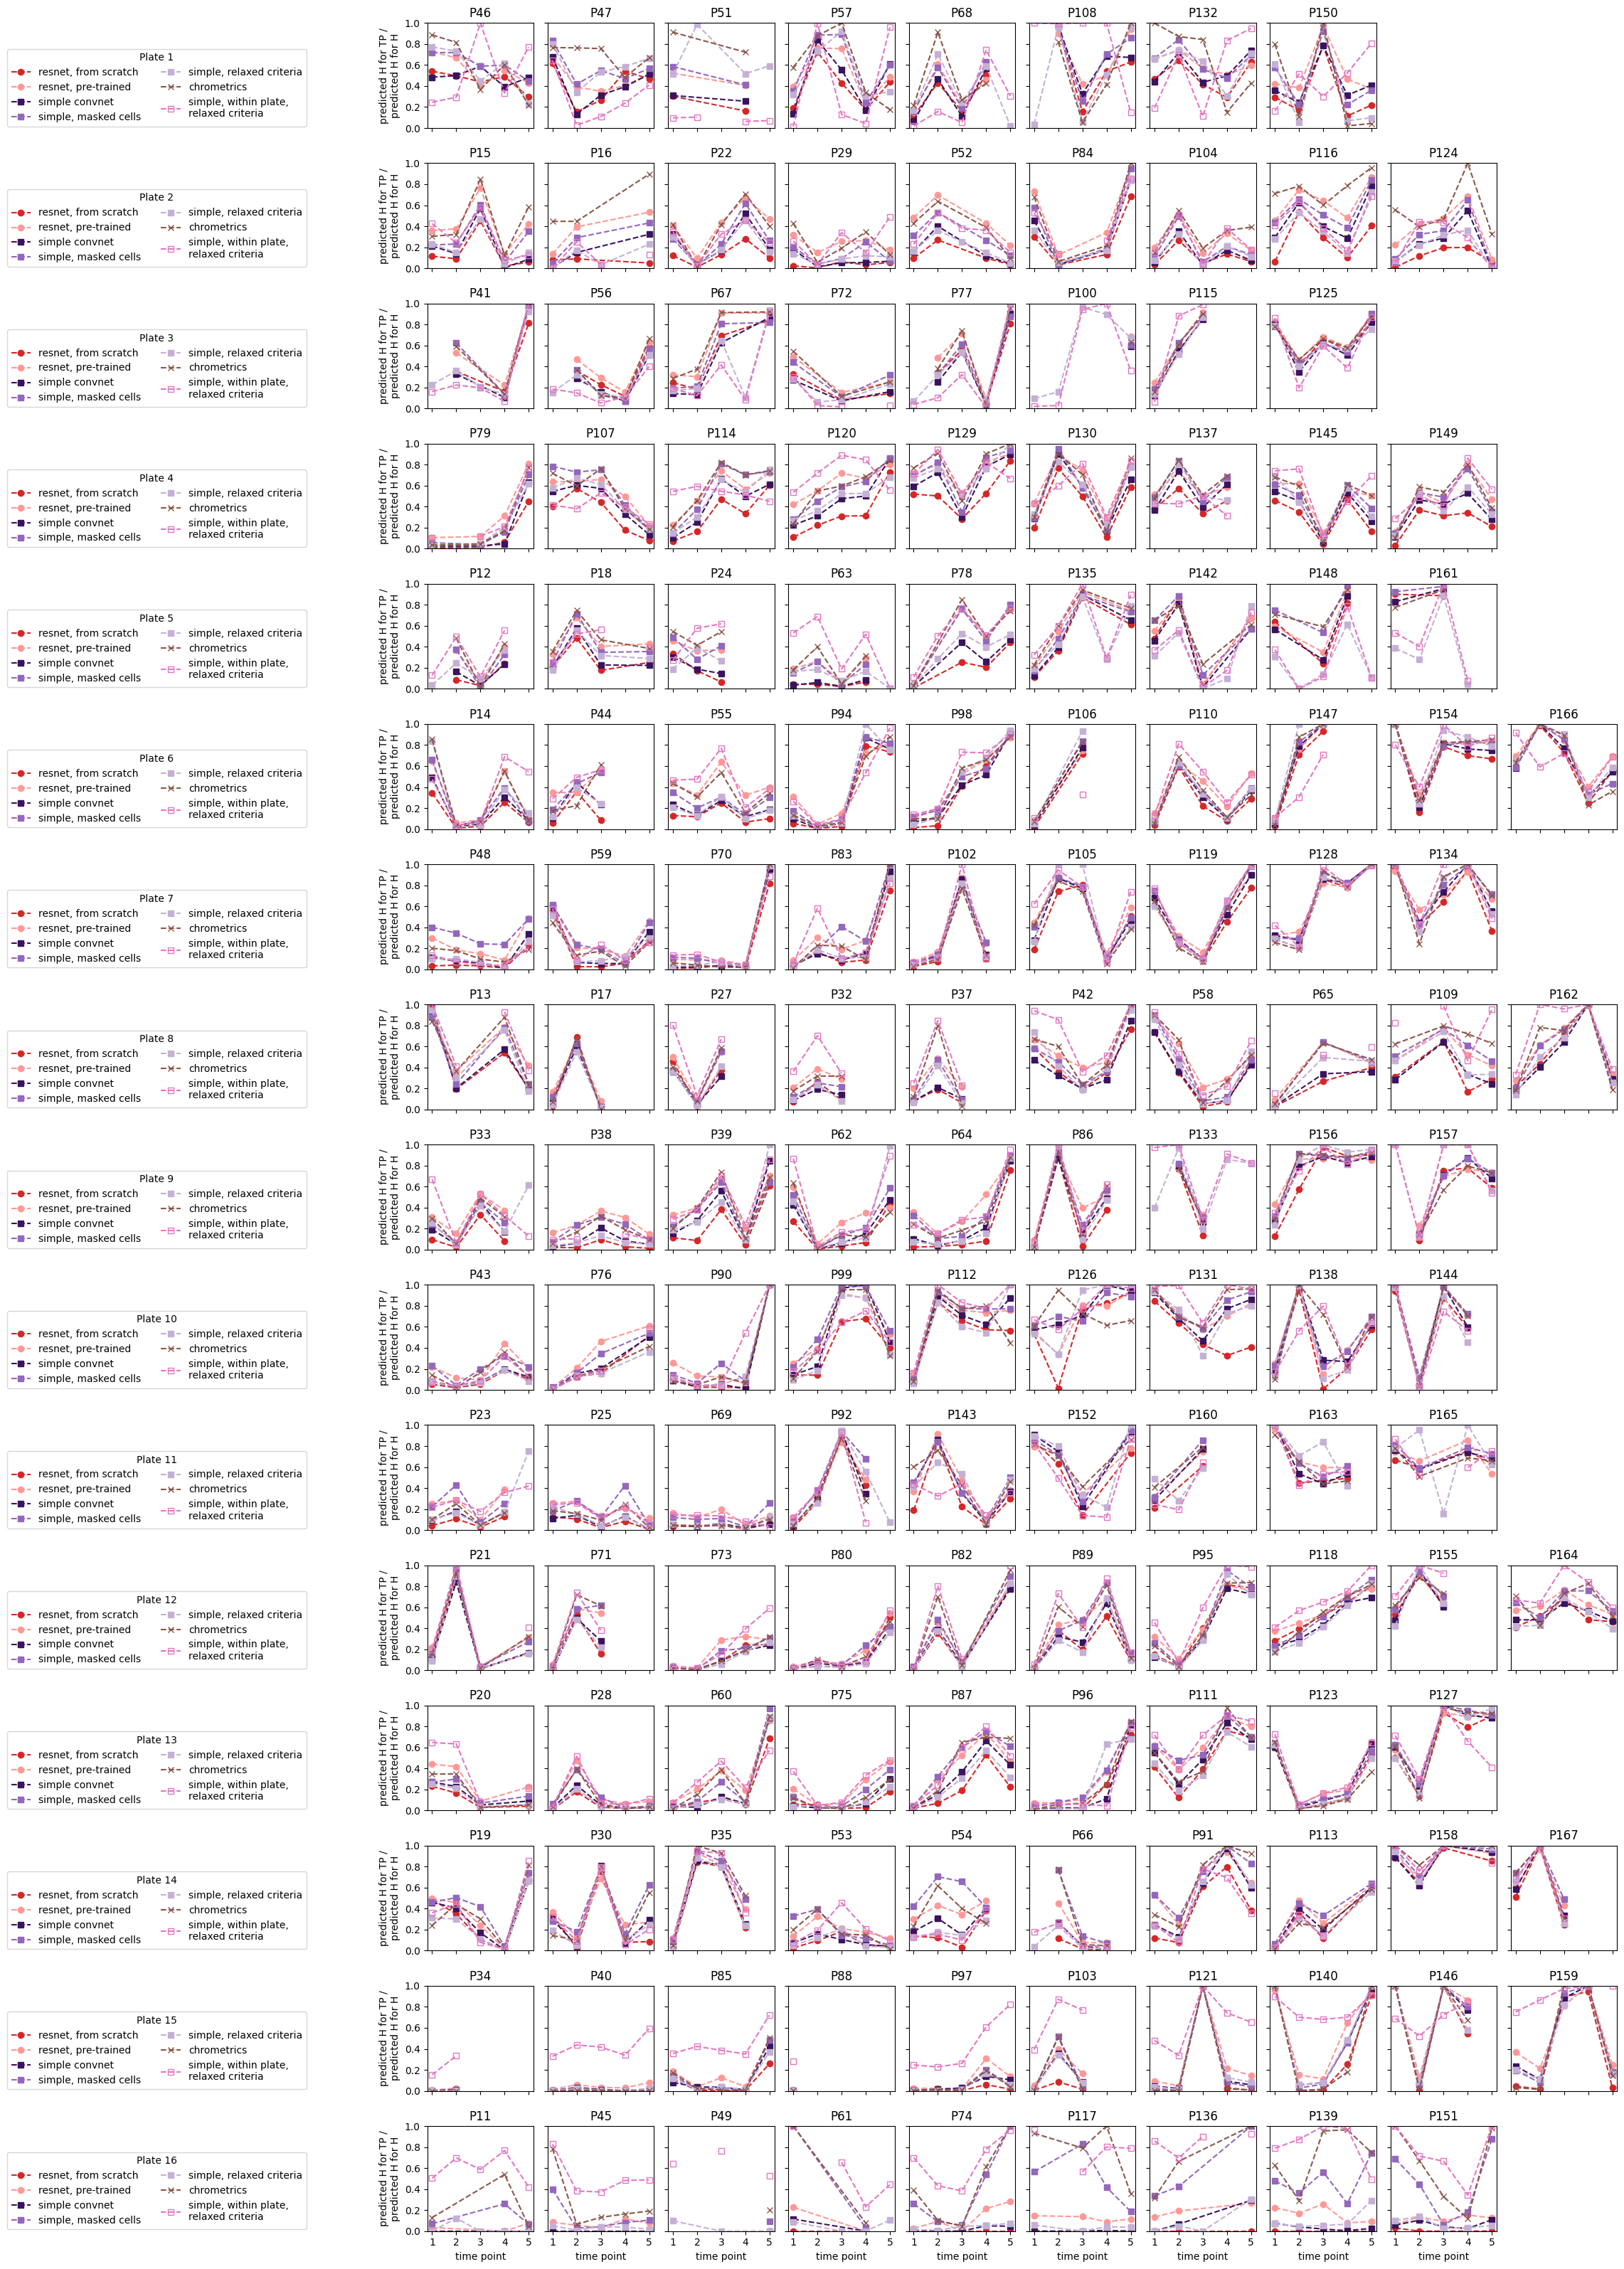

In [10]:
def load_scores(path):  # cap similarity-to-healthy at 1; >1 arises from plate noise / small held-out healthy sample
  res = pd.read_csv(path)
  res['score'] = res['score'].clip(upper=1)
  return res

plates = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
fig, axxs = plt.subplots(len(plates), 10, figsize=(2*10+3, 2*len(plates)), sharey=True, sharex=True)

for plate, axs in zip(plates, axxs):

  res = load_scores('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_scores.csv')
  res = res[res['plate'] == plate]
  patients = res[res['time'] == 1]['patient'].unique()
  pids = [int(p[1:]) for p in patients]
  patients = patients[np.argsort(pids)]
  if len(patients) > 10:  # make sure we're not skipping any while plotting due to lack of space
    print(plate, patients)

  res = load_scores('results/1_16_t01_healthy_cancer_without_plate_by_cell_resnet_from_scratch_scores.csv')
  res = res[res['plate'] == plate]
  for i, (p, ax) in enumerate(zip(patients, axs)):
    pres = res[res['patient'] == p]
    ax.plot(pres['time'], pres['score'], 'o--', label=f'resnet, from scratch', color='#d62728')
    ax.set_title(f'{p}')

  res = load_scores('results/1_16_t01_healthy_cancer_without_plate_by_cell_pretrained_resnet_scores.csv')
  res = res[res['plate'] == plate]
  for i, (p, ax) in enumerate(zip(patients, axs)):
    pres = res[res['patient'] == p]
    ax.plot(pres['time'], pres['score'], 'o--', label=f'resnet, pre-trained', color='#ff9896')
    ax.set_title(f'{p}')

  res = load_scores('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_scores.csv')
  res = res[res['plate'] == plate]
  for i, (p, ax) in enumerate(zip(patients, axs)):
    pres = res[res['patient'] == p]
    ax.plot(pres['time'], pres['score'], 's--', label=f'simple convnet', color="#3a135e")
    ax.set_title(f'{p}')

  res = load_scores('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_masked_scores.csv')
  res = res[res['plate'] == plate]
  for i, (p, ax) in enumerate(zip(patients, axs)):
    pres = res[res['patient'] == p]
    ax.plot(pres['time'], pres['score'], 's--', label=f'simple, masked cells', color='#9467bd')
    ax.set_title(f'{p}')

  res = load_scores('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_scores.csv')
  res = res[res['plate'] == plate]
  for i, (p, ax) in enumerate(zip(patients, axs)):
    pres = res[res['patient'] == p]
    ax.plot(pres['time'], pres['score'], 's--', label=f'simple, relaxed criteria', color="#c5b0d5")
    ax.set_title(f'{p}')

  res = load_scores('results/1_16_t01_healthy_cancer_without_plate_by_cell_chrometrics_scores.csv')
  res = res[res['plate'] == plate]
  for i, (p, ax) in enumerate(zip(patients, axs)):
    pres = res[res['patient'] == p]
    ax.plot(pres['time'], pres['score'], 'x--', label=f'chrometrics', color='#8c564b')
    ax.set_title(f'{p}')

  res = load_scores('results/within_plate_relaxed_mil_architecture_scores.csv')
  res = res[res['plate'] == plate]
  for i, (p, ax) in enumerate(zip(patients, axs)):
    pres = res[res['patient'] == p]
    ax.plot(pres['time'], pres['score'], 's--', label=f'simple, within plate,\nrelaxed criteria', 
            color='#e377c2', markerfacecolor='none')
    ax.set_title(f'{p}')
    
  for ax in axs:
    ax.set_ylim(0, 1)

  if plate == plates[-1]:
    for ax in axs:
      ax.set_xlabel('time point')
      ax.set_xticks([1, 2, 3, 4, 5])

  axs[0].legend(loc='upper left', bbox_to_anchor=(-4, 0.8), title=f'Plate {plate}', ncol=2)
  axs[0].set_ylabel('predicted H for TP /\npredicted H for H')
  for ax in axs[len(patients):]:
    ax.axis('off')

fig.tight_layout()
fig.show()

## Representations and images

In [11]:
data = PlateDataset([3, 4, 5, 6], load_masks=True, load_chrometrics=True, strict_discard=False)


  0%|          | 0/4 [00:00<?, ?it/s]


 25%|██▌       | 1/4 [00:01<00:05,  2.00s/it]


 50%|█████     | 2/4 [00:10<00:11,  5.88s/it]


 75%|███████▌  | 3/4 [00:15<00:05,  5.26s/it]


100%|██████████| 4/4 [00:21<00:00,  5.77s/it]


100%|██████████| 4/4 [00:21<00:00,  5.42s/it]

In [12]:
traj = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_trajectory_classes.csv', index_col='patient')

In [13]:
use_plates = np.array([3, 4, 5, 6])
use_groups = ['healthy', 'H&N cancer'] 

cdf = data.info[data.info['group'].isin(use_groups)].groupby(['patient', 'time'])['cell'].count().reset_index()
cdf = cdf[(cdf['cell'] > 100)]

p01s = cdf[(cdf['time'] == 1) | (cdf['time'] == 0)]['patient'].unique()
p1ts = traj[traj['trajectory'].isin(['up', 'low'])].index.values
p1ts = p1ts[np.isin(p1ts, p01s)]
p1ts

array(['P100', 'P107', 'P110', 'P114', 'P120', 'P130', 'P135', 'P14',
       'P142', 'P145', 'P148', 'P149', 'P18', 'P41', 'P55', 'P56', 'P63',
       'P67', 'P72', 'P77', 'P78', 'P79', 'P94', 'P98'], dtype=object)

In [14]:
p1ths = traj[traj['trajectory'].isin(['up', 'low', 'high'])].index.values
p1ths = p1ths[np.isin(p1ths, p01s)]
p01ths = np.concatenate([p1ths, [h for h in p01s if h[0] == 'H']])
p01ths

array(['P100', 'P107', 'P110', 'P114', 'P120', 'P125', 'P129', 'P130',
       'P135', 'P14', 'P142', 'P145', 'P148', 'P149', 'P154', 'P166',
       'P18', 'P41', 'P55', 'P56', 'P63', 'P67', 'P72', 'P77', 'P78',
       'P79', 'P94', 'P98', 'H06', 'H07', 'H10', 'H22', 'H23', 'H30',
       'H31', 'H37', 'H39', 'H40'], dtype=object)

### Fig. 4d

In [15]:
from torchvision.models import resnet18 as make_resnet18
from torchvision.models.feature_extraction import create_feature_extractor
from torch.utils.data import DataLoader


def extract_resnet_patch_features(imgs, transform=None):
  model = make_resnet18(weights="DEFAULT").to('cuda:0')
  return_nodes = {
      'flatten': 'z',
  }
  device = 'cuda:0'
  feature_extractor = create_feature_extractor(model.eval().to(device), return_nodes=return_nodes)
  z = torch.zeros((len(imgs), 512))
  i = 0
  loader = DataLoader(imgs, batch_size=128, shuffle=False)
  # for batch in tqdm(loader):
  for img_batch in tqdm(loader):
    img_batch = img_batch.to(device).repeat(1, 3, 1, 1)
    if transform is not None:
      img_batch = transform(img_batch)
    with torch.no_grad():
      z[i:i+len(img_batch)] = feature_extractor(img_batch)['z'].cpu()
    i += len(img_batch)
  return z


import os
_cache = 'results/fig4_res_zs.npy'
if os.path.exists(_cache):
    res_zs = torch.from_numpy(np.load(_cache))
else:
    res_zs = extract_resnet_patch_features(data.imgs)
    np.save(_cache, res_zs.numpy())
res_zs.shape

torch.Size([461688, 512])

In [16]:
np.random.seed(1234)

vis_info = []
vis_idx = []
healthy = [h for h in p01ths if h[0] == 'H']
for h in healthy:
    n = 100
    vis_idx.append(np.random.choice(data.info[data.info['plate'].isin(use_plates) & 
                                              data.info['time'].isin([0, 1]) & 
                                              data.info['patient'].isin([h])].index, size=n))
    vis_info.extend([(h, 'healthy')] * n)

tlut = traj.loc[p1ths].reset_index().groupby('trajectory')['patient'].unique()
for p in tlut['high']:
    n = int(100 *  len(healthy) / len(tlut['high']))
    vis_idx.append(np.random.choice(data.info[data.info['plate'].isin(use_plates) & 
                                              data.info['time'].isin([0, 1]) & 
                                              data.info['patient'].isin([p])].index, size=n))
    vis_info.extend([(p, 'high')] * n)

for p in tlut['low']:
    n = int(100 *  len(healthy) / len(tlut['low']))
    vis_idx.append(np.random.choice(data.info[data.info['plate'].isin(use_plates) & 
                                              data.info['time'].isin([0, 1]) & 
                                              data.info['patient'].isin([p])].index, size=n))
    vis_info.extend([(p, 'low')] * n)

for p in tlut['up']:
    n = int(100 *  len(healthy) / len(tlut['up']))
    vis_idx.append(np.random.choice(data.info[data.info['plate'].isin(use_plates) & 
                                              data.info['time'].isin([0, 1]) & 
                                              data.info['patient'].isin([p])].index, size=n))
    vis_info.extend([(p, 'up')] * n)

vis_info = pd.DataFrame(vis_info, columns=['patient', 'group'])
vis_idx = np.concatenate(vis_idx)
vis_info.groupby('group')['patient'].count()

group
healthy    1000
high       1000
low        1000
up          994
Name: patient, dtype: int64

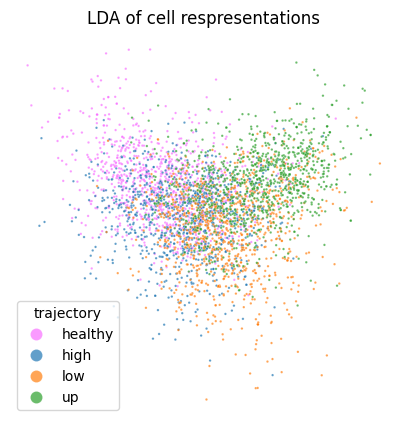

In [17]:
# from sklearn.lda import LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

vis_info['trajectory'] = vis_info['group']
vis_info[['lda_x', 'lda_y']] = LDA(n_components=2).fit(res_zs[vis_idx], vis_info['trajectory']).transform(res_zs[vis_idx])


fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.scatterplot(data=vis_info, x='lda_x', y='lda_y', hue='trajectory', s=3, ax=ax, alpha=0.7,
                 palette={'up' : '#2ca02c', 'low' : '#ff7f0e', 'high' : '#1f77b4', 'healthy' :  '#f970ff'})
ax.set_title('LDA of cell respresentations')
sns.move_legend(ax, 'best', markerscale=5)
ax.axis('off');

### Fig. S4b

In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


def get_vis_idx(t, cdf, use_plates, traj, show_classes=['up', 'low', 'high']):
    p01s = cdf[(cdf['time'] == t) | (cdf['time'] == 0)]['patient'].unique()
    p1ts = traj[traj['trajectory'].isin(show_classes)].index.values
    p1ts = p1ts[np.isin(p1ts, p01s)]

    np.random.seed(1234)

    vis_info = []
    vis_idx = []
    healthy = [h for h in p01s if h[0] == 'H']
    for h in healthy:
        n = 100
        vis_idx.append(np.random.choice(data.info[data.info['plate'].isin(use_plates) & 
                                                data.info['time'].isin([0, t]) & 
                                                data.info['patient'].isin([h])].index, size=n))
        vis_info.extend([(h, 'healthy')] * n)

    tlut = traj.loc[p1ts].reset_index().groupby('trajectory')['patient'].unique()
    for tj in tlut.index:
        for p in tlut[tj]:
            n = int(100 *  len(healthy) / len(tlut[tj]))
            vis_idx.append(np.random.choice(data.info[data.info['plate'].isin(use_plates) & 
                                                    data.info['time'].isin([0, t]) & 
                                                    data.info['patient'].isin([p])].index, size=n))
            vis_info.extend([(p, tj)] * n)

    vis_info = pd.DataFrame(vis_info, columns=['patient', 'group'])
    vis_idx = np.concatenate(vis_idx)
    return vis_idx, vis_info


def make_lda_plots(use_groups, use_plates, traj, fig_scale=5, legend=True, show_classes=['up', 'low', 'high']):
    cdf = data.info[data.info['group'].isin(use_groups) & data.info['plate'].isin(use_plates)].groupby(['patient', 'time'])['cell'].count().reset_index()
    cdf = cdf[(cdf['cell'] > 100)]

    fig, axs = plt.subplots(1, 5, figsize=(5*fig_scale, fig_scale))
    for t, ax in zip([1, 2, 3, 4, 5], axs):
        vis_idx, vis_info = get_vis_idx(t, cdf, use_plates, traj, show_classes)
        print(f'cell counts used for time {t}', vis_info.groupby('group')['patient'].count())

        vis_info['trajectory'] = vis_info['group']
        vis_info[['lda_x', 'lda_y']] = LDA(n_components=2).fit(res_zs[vis_idx], vis_info['trajectory']).transform(res_zs[vis_idx])

        sns.scatterplot(data=vis_info, x='lda_x', y='lda_y', hue='trajectory', s=3, ax=ax, alpha=0.7, legend=legend,
                        palette={'up' : '#2ca02c', 'low' : '#ff7f0e', 'high' : '#1f77b4', 'healthy' :  '#f970ff'})
        ax.set_title(f'LDA of cell respresentations\nfrom time point {t}')
        if legend:
            sns.move_legend(ax, 'best', markerscale=5)
        ax.axis('off');
    fig.tight_layout()
    fig.show()


def make_lda_plots_color_low_pats(use_groups, use_plates, traj, fig_scale=5, show_classes=['up', 'low', 'high'], legend=True):
    cdf = data.info[data.info['group'].isin(use_groups) & data.info['plate'].isin(use_plates)].groupby(['patient', 'time'])['cell'].count().reset_index()
    cdf = cdf[(cdf['cell'] > 100)]

    fig, axs = plt.subplots(1, 5, figsize=(5*fig_scale, fig_scale))
    for t, ax in zip([1, 2, 3, 4, 5], axs):
        vis_idx, vis_info = get_vis_idx(t, cdf, use_plates, traj, show_classes)
        print(f'cell counts used for time {t}', vis_info.groupby('group')['patient'].count())

        vis_info['trajectory'] = vis_info['group']
        vis_info[['lda_x', 'lda_y']] = LDA(n_components=2).fit(res_zs[vis_idx], vis_info['trajectory']).transform(res_zs[vis_idx])

        sns.scatterplot(data=vis_info[vis_info['group'] != 'low'], x='lda_x', y='lda_y', color='black', 
                        label='other', alpha=0.3, s=3, ax=ax, legend=legend)

        if t == 1:
            patients = vis_info[vis_info['group'] == 'low']['patient'].unique()
            pids = [int(p[1:]) for p in patients]
            patients = patients[np.argsort(pids)]
        sns.scatterplot(data=vis_info[vis_info['group'] == 'low'], x='lda_x', y='lda_y', hue='patient', s=5, ax=ax, 
                        hue_order=patients, legend=legend)

        ax.set_title(f'LDA of cell respresentations\nfrom time point {t}')
        if legend:
          sns.move_legend(ax, 'upper left', markerscale=5, bbox_to_anchor=(-0.1, 0), ncol=3, title='low patient') 
        ax.axis('off');
    fig.tight_layout()
    fig.show()

cell counts used for time 1 group
healthy    1000
high       1000
low        1000
up          994
Name: patient, dtype: int64


cell counts used for time 2 group
healthy    1000
high       1000
low        1000
up          988
Name: patient, dtype: int64


cell counts used for time 3 group
healthy    1000
high       1000
low        1000
up          994
Name: patient, dtype: int64


cell counts used for time 4 group
healthy    1000
high       1000
low        1000
up          994
Name: patient, dtype: int64


cell counts used for time 5 group
healthy    1000
high       1000
low        1000
up          994
Name: patient, dtype: int64


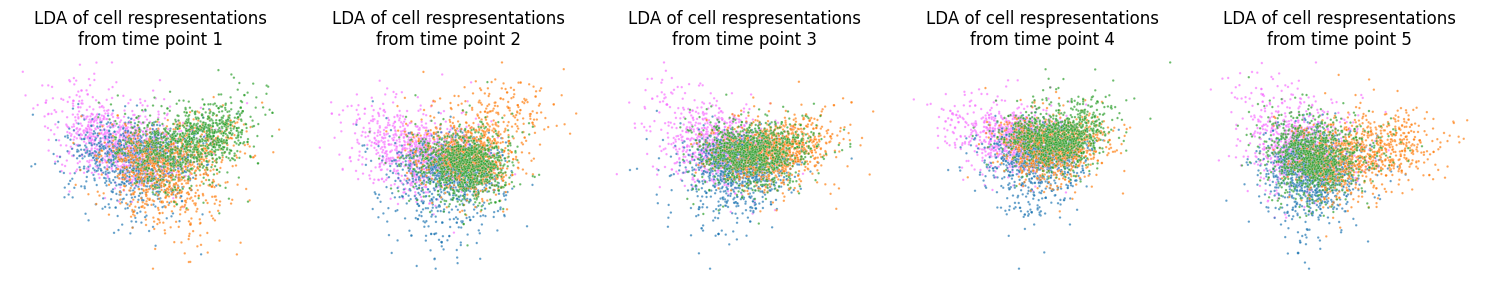

In [19]:
make_lda_plots(use_groups, use_plates, traj, fig_scale=3, legend=False)

cell counts used for time 1 group
healthy    1000
high       1000
low        1000
up          994
Name: patient, dtype: int64


cell counts used for time 2 group
healthy    1000
high       1000
low        1000
up          988
Name: patient, dtype: int64


cell counts used for time 3 group
healthy    1000
high       1000
low        1000
up          994
Name: patient, dtype: int64


cell counts used for time 4 group
healthy    1000
high       1000
low        1000
up          994
Name: patient, dtype: int64


cell counts used for time 5 group
healthy    1000
high       1000
low        1000
up          994
Name: patient, dtype: int64


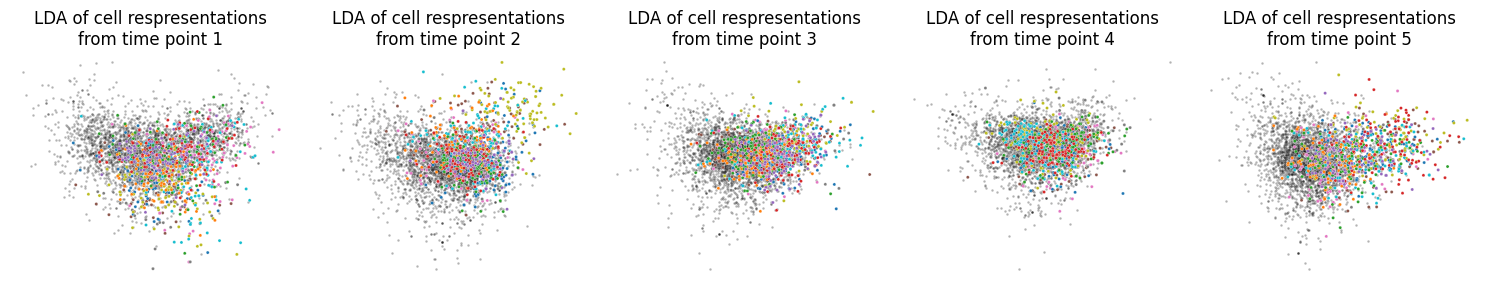

In [20]:
make_lda_plots_color_low_pats(use_groups, use_plates, traj, fig_scale=3, legend=False)

### Fig. 4g

In [21]:
healthy = data.info[data.info['group'] == 'healthy']['patient'].unique()
for h in healthy:
    traj.loc[h, 'trajectory'] = None

In [22]:
groups = pd.read_csv('meta/patient_diagnosis_groups.csv')
groups = groups.set_index('patient')
groups

,group
patient,
P11,Sarcoma-Rhabdomyosarcoma
P12,H&N cancer
P13,Lymphoma
P14,H&N cancer
P15,CNS-Glioma
...,...
H46,healthy
H47,healthy
H48,healthy


In [23]:
def eval_model(classifier_name, loader, branches=5, classes=1):
    if classes > 1:
      classifier = GatedAttentionMulti(classes=classes, branches=branches)
    else:
      classifier = GatedAttention(branches=branches)
    classifier = classifier.to(device)
    classifier.load_state_dict(torch.load(f'/ewsc/hschluet/models/pbmc5/revision_rerun/{classifier_name}_model.pt', weights_only=True, map_location=device))
    classifier.eval()

    np.random.seed(1232412)
    torch.manual_seed(124514)
    torch.cuda.manual_seed_all(13513)

    bag_labs = []
    bag_pred = []
    bag_ids = []
    bag_attn = []
    bag_rattn = []
    bag_zs = []
    bag_pats = []
    bag_groups = []
    bags = []
    masks = []
    for i, (bag, mask, lab, pat, group) in enumerate(loader):
        with torch.no_grad():
            _, pred, attn, rattn, z = classifier(bag.to(device))
        bag_ids.extend([i] * 50)
        bag_pats.extend([pat] * 50)
        bag_groups.extend([group] * 50)
        bag_labs.extend([lab.item()] * 50)
        bag_pred.extend([pred.cpu().item()] * 50)
        if branches == 1:
            bag_attn.extend(attn.cpu().squeeze().numpy())
            bag_rattn.extend(rattn.cpu().squeeze().numpy())
        else:
            bag_attn.extend(attn.T.cpu().squeeze().numpy())
            bag_rattn.extend(rattn.T.cpu().squeeze().numpy())
        bag_zs.extend(z.cpu().numpy())
        bags.extend(bag.cpu().numpy())
        masks.extend(mask.cpu().numpy())

    df = pd.DataFrame()
    df['lab'] = bag_labs
    df['pred'] = bag_pred
    df['i'] = bag_ids
    df['pat'] = bag_pats
    df['group'] = bag_groups
    if branches == 1:
        df['attention'] = bag_attn
        df['raw attention'] = bag_rattn
    else:
        df[[f'attention {i}' for i in range(branches)]] = bag_attn
        df[[f'raw attention {i}' for i in range(branches)]] = bag_rattn
    return df, bag_zs, bags, masks


def eval_model_with_chrometric(classifier_name, loader, branches=5, classes=1):
    if classes > 1:
      classifier = GatedAttentionMulti(classes=classes, branches=branches)
    else:
      classifier = GatedAttention(branches=branches)
    classifier = classifier.to(device)
    classifier.load_state_dict(torch.load(f'/ewsc/hschluet/models/pbmc5/revision_rerun/{classifier_name}_model.pt', weights_only=True, map_location=device))
    classifier.eval()

    np.random.seed(1232412)
    torch.manual_seed(124514)
    torch.cuda.manual_seed_all(13513)

    bag_labs = []
    bag_pred = []
    bag_ids = []
    bag_attn = []
    bag_rattn = []
    bag_zs = []
    bag_pats = []
    bag_groups = []
    bags = []
    masks = []
    chrometrics = []
    for i, (bag, mask, lab, pat, group, cs) in enumerate(loader):
        with torch.no_grad():
            _, pred, attn, rattn, z = classifier(bag.to(device))
        bag_ids.extend([i] * 50)
        bag_pats.extend([pat] * 50)
        bag_groups.extend([group] * 50)
        bag_labs.extend([lab.item()] * 50)
        bag_pred.extend([pred.cpu().item()] * 50)
        if branches == 1:
            bag_attn.extend(attn.cpu().squeeze().numpy())
            bag_rattn.extend(rattn.cpu().squeeze().numpy())
        else:
            bag_attn.extend(attn.T.cpu().squeeze().numpy())
            bag_rattn.extend(rattn.T.cpu().squeeze().numpy())
        bag_zs.extend(z.cpu().numpy())
        bags.extend(bag.cpu().numpy())
        masks.extend(mask.cpu().numpy())
        chrometrics.append(cs)

    df = pd.DataFrame()
    df['lab'] = bag_labs
    df['pred'] = bag_pred
    df['i'] = bag_ids
    df['pat'] = bag_pats
    df['group'] = bag_groups
    if branches == 1:
        df['attention'] = bag_attn
        df['raw attention'] = bag_rattn
    else:
        df[[f'attention {i}' for i in range(branches)]] = bag_attn
        df[[f'raw attention {i}' for i in range(branches)]] = bag_rattn
    chrometrics = pd.concat(chrometrics, ignore_index=True)
    return df, bag_zs, bags, masks, chrometrics


def test_up_vs_low_bagloader(bag_size=50, reps=11, use_patients=p1ts, use_times=[1], use_plates=use_plates, device=device, 
                             transform=T.CenterCrop(28), use_groups=use_groups, return_chrometric=False):
  use_idx = torch.argwhere(torch.from_numpy((data.info['plate'].isin(use_plates) & data.info['time'].isin(use_times) & data.info['group'].isin(use_groups)).values)).flatten()
  use_data = transform(data.imgs[use_idx].to(device))
  use_masks = transform(data.masks[use_idx].to(device))
  if return_chrometric:
    use_chrometric = data.chrometrics.iloc[use_idx].reset_index()
  
  pat_plates = data.info.groupby(['patient'])['plate'].unique()
  for pat in use_patients:
    if not np.isin(pat_plates[pat], use_plates).any() or not groups.loc[pat, 'group'] in use_groups:
      continue
    pat_idx = torch.argwhere(torch.from_numpy((data.info.loc[use_idx]['patient'] == pat).values)).flatten().to(device)
    for _ in range(reps):
      idx = torch_random_choice(pat_idx, size=bag_size)
      xs = use_data[idx]
      t = traj.loc[pat, 'trajectory']
      label = 1 if t == 'up' else 0
      if not return_chrometric:
        yield xs.float(), use_masks[idx], torch.tensor(label).to(device), pat, t
      else: 
        yield xs.float(), use_masks[idx], torch.tensor(label).to(device), pat, t, use_chrometric.loc[idx.cpu().numpy()]

In [24]:
name = '3_6_traj'
group = 'H&N cancer'

test_loader = test_up_vs_low_bagloader(use_groups=[group], use_patients=p1ts, return_chrometric=True)
res_df, zs, imgs, masks, chrometrics = eval_model_with_chrometric(name, test_loader) 
res_df

,lab,pred,i,pat,group,attention 0,attention 1,attention 2,attention 3,attention 4,raw attention 0,raw attention 1,raw attention 2,raw attention 3,raw attention 4
0,1,1.0,0,P100,up,0.008291,0.010193,0.018192,0.013299,0.014291,-0.109040,0.839255,0.331053,1.829258,1.998480
1,1,1.0,0,P100,up,0.008371,0.010134,0.016904,0.012312,0.012192,-0.099401,0.833397,0.257608,1.752117,1.839660
2,1,1.0,0,P100,up,0.007999,0.011132,0.020802,0.014807,0.018895,-0.144903,0.927351,0.465089,1.936630,2.277733
3,1,1.0,0,P100,up,0.027083,0.075271,0.014360,0.212091,0.001769,1.074746,2.838611,0.094495,4.598565,-0.090521
4,1,1.0,0,P100,up,0.007409,0.010699,0.021251,0.012564,0.023846,-0.221438,0.887655,0.486475,1.772376,2.510483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13195,1,1.0,263,P98,up,0.004605,0.006368,0.025481,0.003364,0.033525,-0.488981,0.660819,0.644591,1.086229,2.839288
13196,1,1.0,263,P98,up,0.006041,0.008151,0.020752,0.007026,0.019179,-0.217572,0.907667,0.439280,1.822747,2.280785
13197,1,1.0,263,P98,up,0.007579,0.008982,0.014813,0.007103,0.011189,0.009347,1.004796,0.102148,1.833558,1.741900
13198,1,1.0,263,P98,up,0.055339,0.008559,0.013733,0.000240,0.001671,1.997415,0.956604,0.026440,-1.556038,-0.159527


In [25]:
(res_df['pred'] == res_df['lab']).mean()

np.float64(0.9015151515151515)

In [26]:
np.random.seed(1234)
# vis_idx = np.random.choice(np.arange(len(res_df)), replace=False, size=5000)
vis_idx = np.arange(len(res_df))
res_df[['umap_x', 'umap_y']] = np.nan
res_df.loc[vis_idx, ['umap_x', 'umap_y']] = umap.UMAP(random_state=123).fit_transform(np.array(zs)[vis_idx])

/ewsc/hschluet/conda_stuff/anaconda3/envs/new-img-39/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


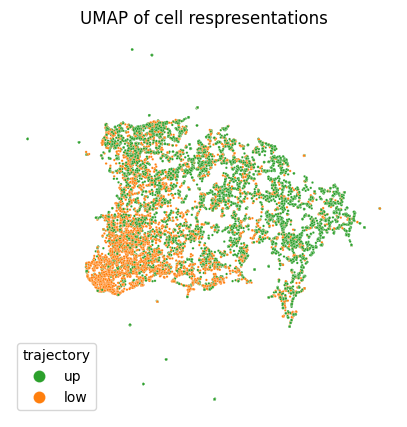

In [27]:
res_df.loc[res_df['lab'] == 1, 'trajectory'] = 'up'
res_df.loc[res_df['lab'] == 0, 'trajectory'] = 'low'

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.scatterplot(data=res_df, x='umap_x', y='umap_y', hue='trajectory', s=3, ax=ax, palette={'up' : '#2ca02c', 'low' : '#ff7f0e'})
ax.set_title('UMAP of cell respresentations')
sns.move_legend(ax, 'lower left', markerscale=5)
ax.axis('off');

In [28]:
res_df['total attention'] = res_df['attention 0'] + res_df['attention 1'] + res_df['attention 2'] + res_df['attention 3']  +res_df['attention 4']
correct_low_bags = res_df[(res_df['lab'] == res_df['pred']) & (res_df['trajectory'] == 'low')]['i'].unique()
correct_up_bags = res_df[(res_df['lab'] == res_df['pred']) & (res_df['trajectory'] == 'up')]['i'].unique()

In [29]:
img_array = np.array(imgs).reshape((264, 50, 1, 28, 28))
mask_array = np.array(masks).reshape((264, 50, 1, 28, 28))
img_array.shape

(264, 50, 1, 28, 28)

### Fig. 4i

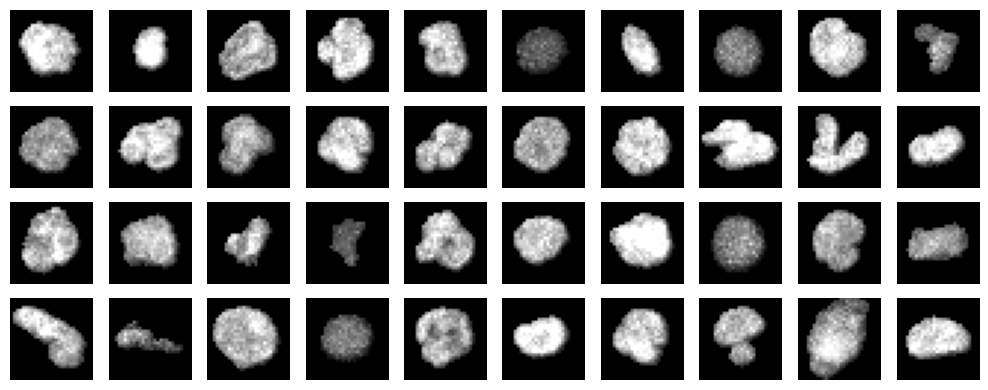

In [30]:
top_up_imgs = []
top_up_masks = []
for i in correct_up_bags:
    idx = res_df[res_df['i'] == i]['total attention'].argsort().values[-3:]  # take last 3
    top_up_imgs.extend(img_array[i, idx])
    top_up_masks.extend(mask_array[i, idx])
top_up_imgs = np.array(top_up_imgs)
top_up_masks = np.array(top_up_masks)

np.random.seed(25323)
fig, axxs = plt.subplots(4, 10, figsize=(10, 4))
show_idx = np.random.choice(np.arange(len(top_up_imgs)), replace=False, size=40)
for im, m, ax in zip(top_up_imgs[show_idx], top_up_masks[show_idx], axxs.flatten()):
    ax.imshow((im * m).squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
fig.tight_layout()
fig.show()

### Fig. 4h

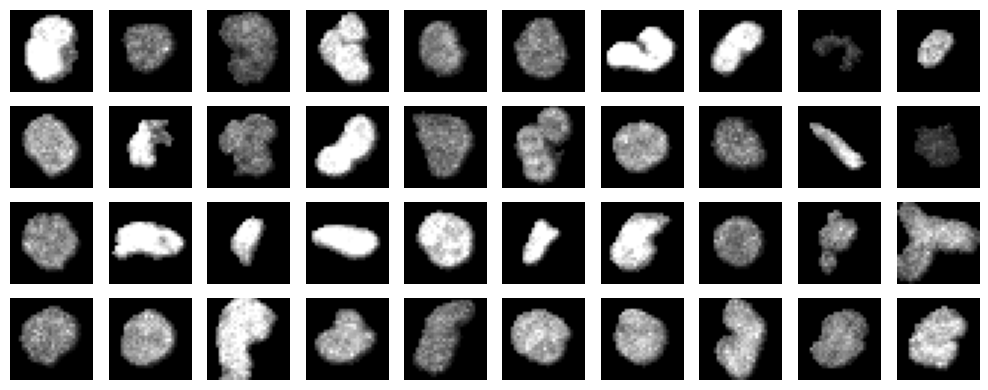

In [31]:
top_low_imgs = []
top_low_masks = []
for i in correct_low_bags:
    idx = res_df[res_df['i'] == i]['total attention'].argsort().values[-3:]  # take last 3
    top_low_imgs.extend(img_array[i, idx])
    top_low_masks.extend(mask_array[i, idx])
top_low_imgs = np.array(top_low_imgs)
top_low_masks = np.array(top_low_masks)

np.random.seed(51313)
fig, axxs = plt.subplots(4, 10, figsize=(10, 4))
show_idx = np.random.choice(np.arange(len(top_low_imgs)), replace=False, size=40)
for im, m, ax in zip(top_low_imgs[show_idx], top_low_masks[show_idx], axxs.flatten()):
    ax.imshow((im * m).squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
fig.tight_layout()
fig.show()

## Compare chrometric features for high vs. low attention

In [32]:
top_up_idx = []
for i in correct_up_bags:
    idx = res_df[res_df['i'] == i]['total attention'].argsort().values[-3:]  # take last 3
    top_up_idx.append(i * 50 + idx)
top_up_idx = np.concatenate(top_up_idx)

top_low_idx = []
for i in correct_low_bags:
    idx = res_df[res_df['i'] == i]['total attention'].argsort().values[-3:]  # take last 3
    top_low_idx.append(i * 50 + idx)
top_low_idx = np.concatenate(top_low_idx)

In [33]:
bot_up_idx = []
for i in correct_up_bags:
    idx = res_df[res_df['i'] == i]['total attention'].argsort().values[:3]  # take first 3
    bot_up_idx.append(i * 50 + idx)
bot_up_idx = np.concatenate(bot_up_idx)

bot_low_idx = []
for i in correct_low_bags:
    idx = res_df[res_df['i'] == i]['total attention'].argsort().values[:3]  # take first 3
    bot_low_idx.append(i * 50 + idx)
bot_low_idx = np.concatenate(bot_low_idx)

In [34]:
print(len(bot_low_idx), len(bot_up_idx), len(top_up_idx), len(top_low_idx))
m = min(len(bot_low_idx), len(bot_up_idx), len(top_up_idx), len(top_low_idx))

312 402 402 312


In [35]:
cnt = []
for col in chrometrics.columns[1:]:
    cnt.append((chrometrics.loc[res_df['lab'] == 0, col].isna().sum(), len(chrometrics.loc[res_df['lab'] == 0, col]), 
                chrometrics.loc[res_df['lab'] == 1, col].isna().sum(), len(chrometrics.loc[res_df['lab'] == 1, col].isna())))
cnt = pd.DataFrame(cnt, index=chrometrics.columns[1:], columns=['lab 0 nan', 'lab 0 cnt', 'lab 1 nan', 'lab 1 cnt'])
cnt
nan_cnt = cnt[(cnt['lab 0 nan'] != 0) | (cnt['lab 1 nan'] != 0)]
bad_cols = nan_cnt.index
nan_cnt

,lab 0 nan,lab 0 cnt,lab 1 nan,lab 1 cnt
max_neg_curv,110,5500,168,7700
avg_neg_curv,110,5500,168,7700
med_neg_curv,110,5500,168,7700
std_neg_curv,110,5500,168,7700
sum_neg_curv,110,5500,168,7700
len_neg_curv,110,5500,168,7700
prominance_prominant_pos_curv,376,5500,742,7700
width_prominant_pos_curv,376,5500,742,7700
prominant_pos_curv,376,5500,742,7700
prominance_prominant_neg_curv,2308,5500,3906,7700


In [36]:
bot_cnt = []
for col in chrometrics.columns[1:]:
    bot_cnt.append((chrometrics.loc[bot_low_idx, col].isna().sum(), len(chrometrics.loc[bot_low_idx, col]), 
                    chrometrics.loc[bot_up_idx, col].isna().sum(), len(chrometrics.loc[bot_up_idx, col])))
bot_cnt = pd.DataFrame(bot_cnt, index=chrometrics.columns[1:], columns=['lab 0 nan', 'lab 0 cnt', 'lab 1 nan', 'lab 1 cnt'])

bot_ps_h = []
bot_ps_c = []
np.random.seed(5213)
for col in chrometrics.columns[1:]:
    bot_ps_h.append(stats.kstest(chrometrics.loc[np.random.choice(top_up_idx, size=m, replace=False), col].values, 
                                 chrometrics.loc[np.random.choice(bot_up_idx, size=m, replace=False), col].values).pvalue)
    bot_ps_c.append(stats.kstest(chrometrics.loc[np.random.choice(top_low_idx, size=m, replace=False), col].values, 
                                 chrometrics.loc[np.random.choice(bot_low_idx, size=m, replace=False), col].values).pvalue)
bot_ps_h = np.array(bot_ps_h)
bot_ps_c = np.array(bot_ps_c)
bot_cnt['p-val (up)'] = bot_ps_h
bot_cnt['p-val (low)'] = bot_ps_c
bot_cnt = bot_cnt[~(bot_cnt.index.isin(bad_cols))].sort_values('p-val (up)')
bot_cnt

,lab 0 nan,lab 0 cnt,lab 1 nan,lab 1 cnt,p-val (up),p-val (low)
skewness,0,312,0,402,1.159829e-50,5.719563e-64
weighted_moments_hu-0,0,312,0,402,2.938174e-37,3.954071e-23
int_sd,0,312,0,402,2.441959e-35,1.296143e-62
int_d75,0,312,0,402,7.217688e-35,1.317427e-26
hc_content_ec_content,0,312,0,402,1.435266e-32,1.176600e-46
...,...,...,...,...,...,...
correlation_100,0,312,0,402,1.000000e+00,1.000000e+00
homogeneity_100,0,312,0,402,1.000000e+00,1.000000e+00
asm_100,0,312,0,402,1.000000e+00,1.000000e+00
contrast_100,0,312,0,402,1.000000e+00,1.000000e+00


### Fig. S4k

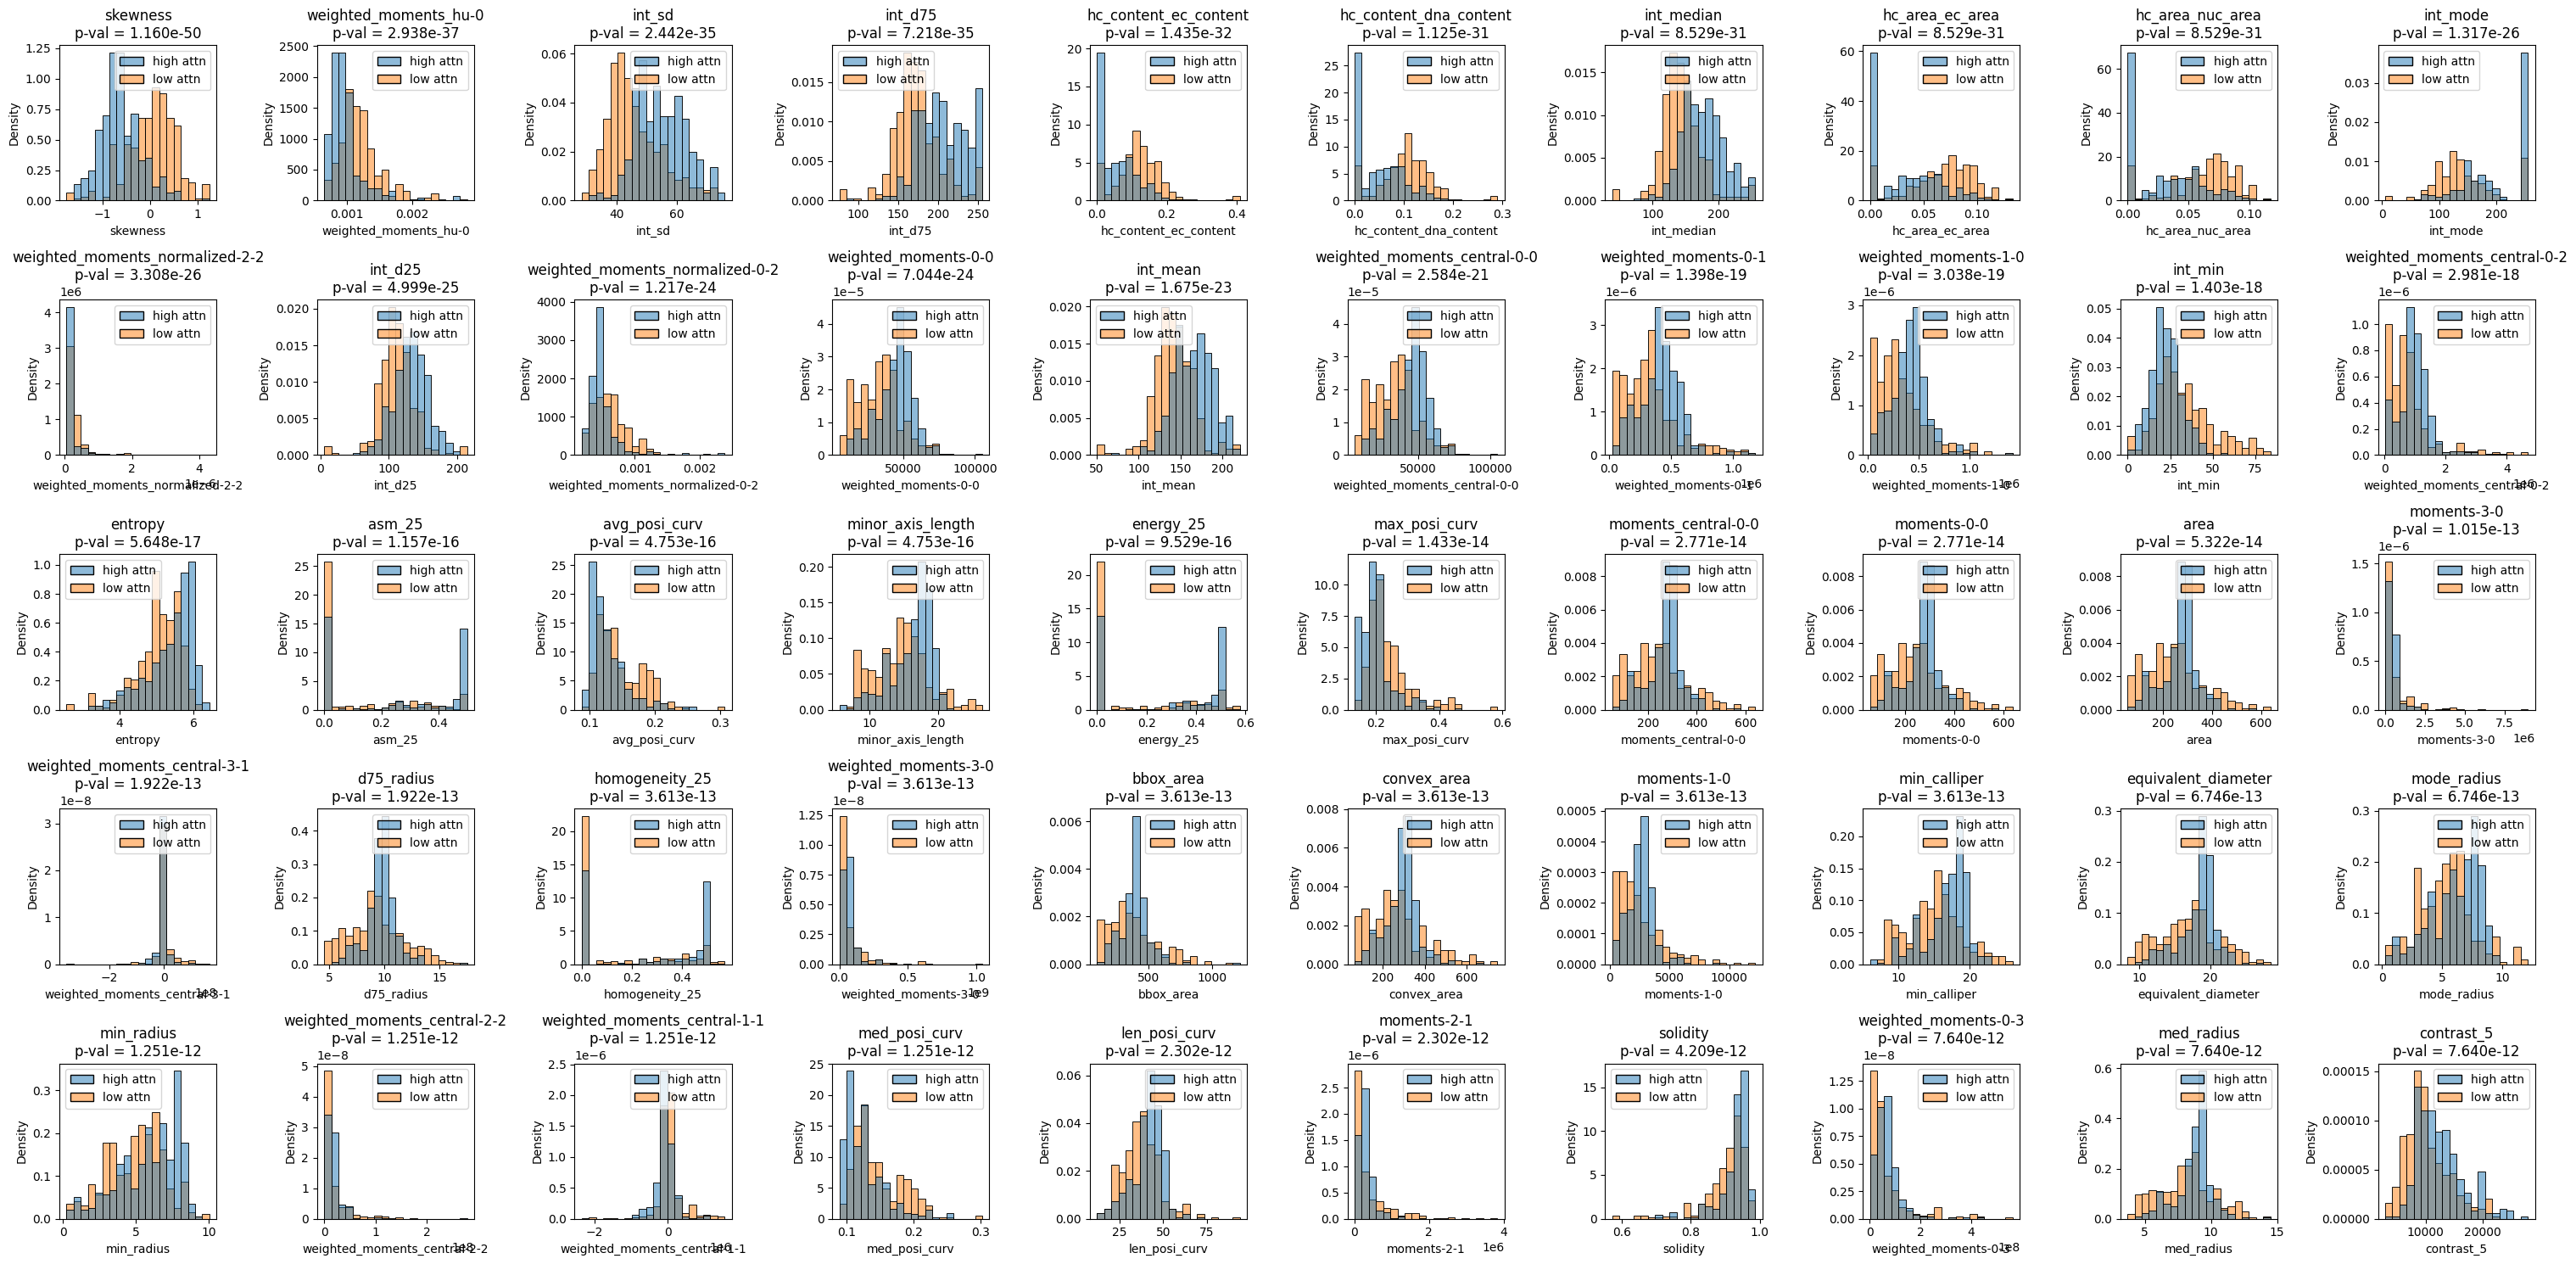

In [37]:
fig, axs = plt.subplots(5, 10, figsize=(30, 15))
for ax, col in zip(axs.flatten(), bot_cnt.sort_values('p-val (up)').index):
    sns.histplot(data=chrometrics.loc[np.concatenate((top_up_idx, bot_up_idx))], x=col, 
                 hue=['high attn'] * len(top_up_idx) + ['low attn'] * len(bot_up_idx) , ax=ax, bins=20, 
                 common_norm=False, stat='density')
    p = bot_cnt.loc[col, 'p-val (up)']
    ax.set_title(f'{col}\np-val = {p:0.3e}')
fig.tight_layout()

### Fig S4j

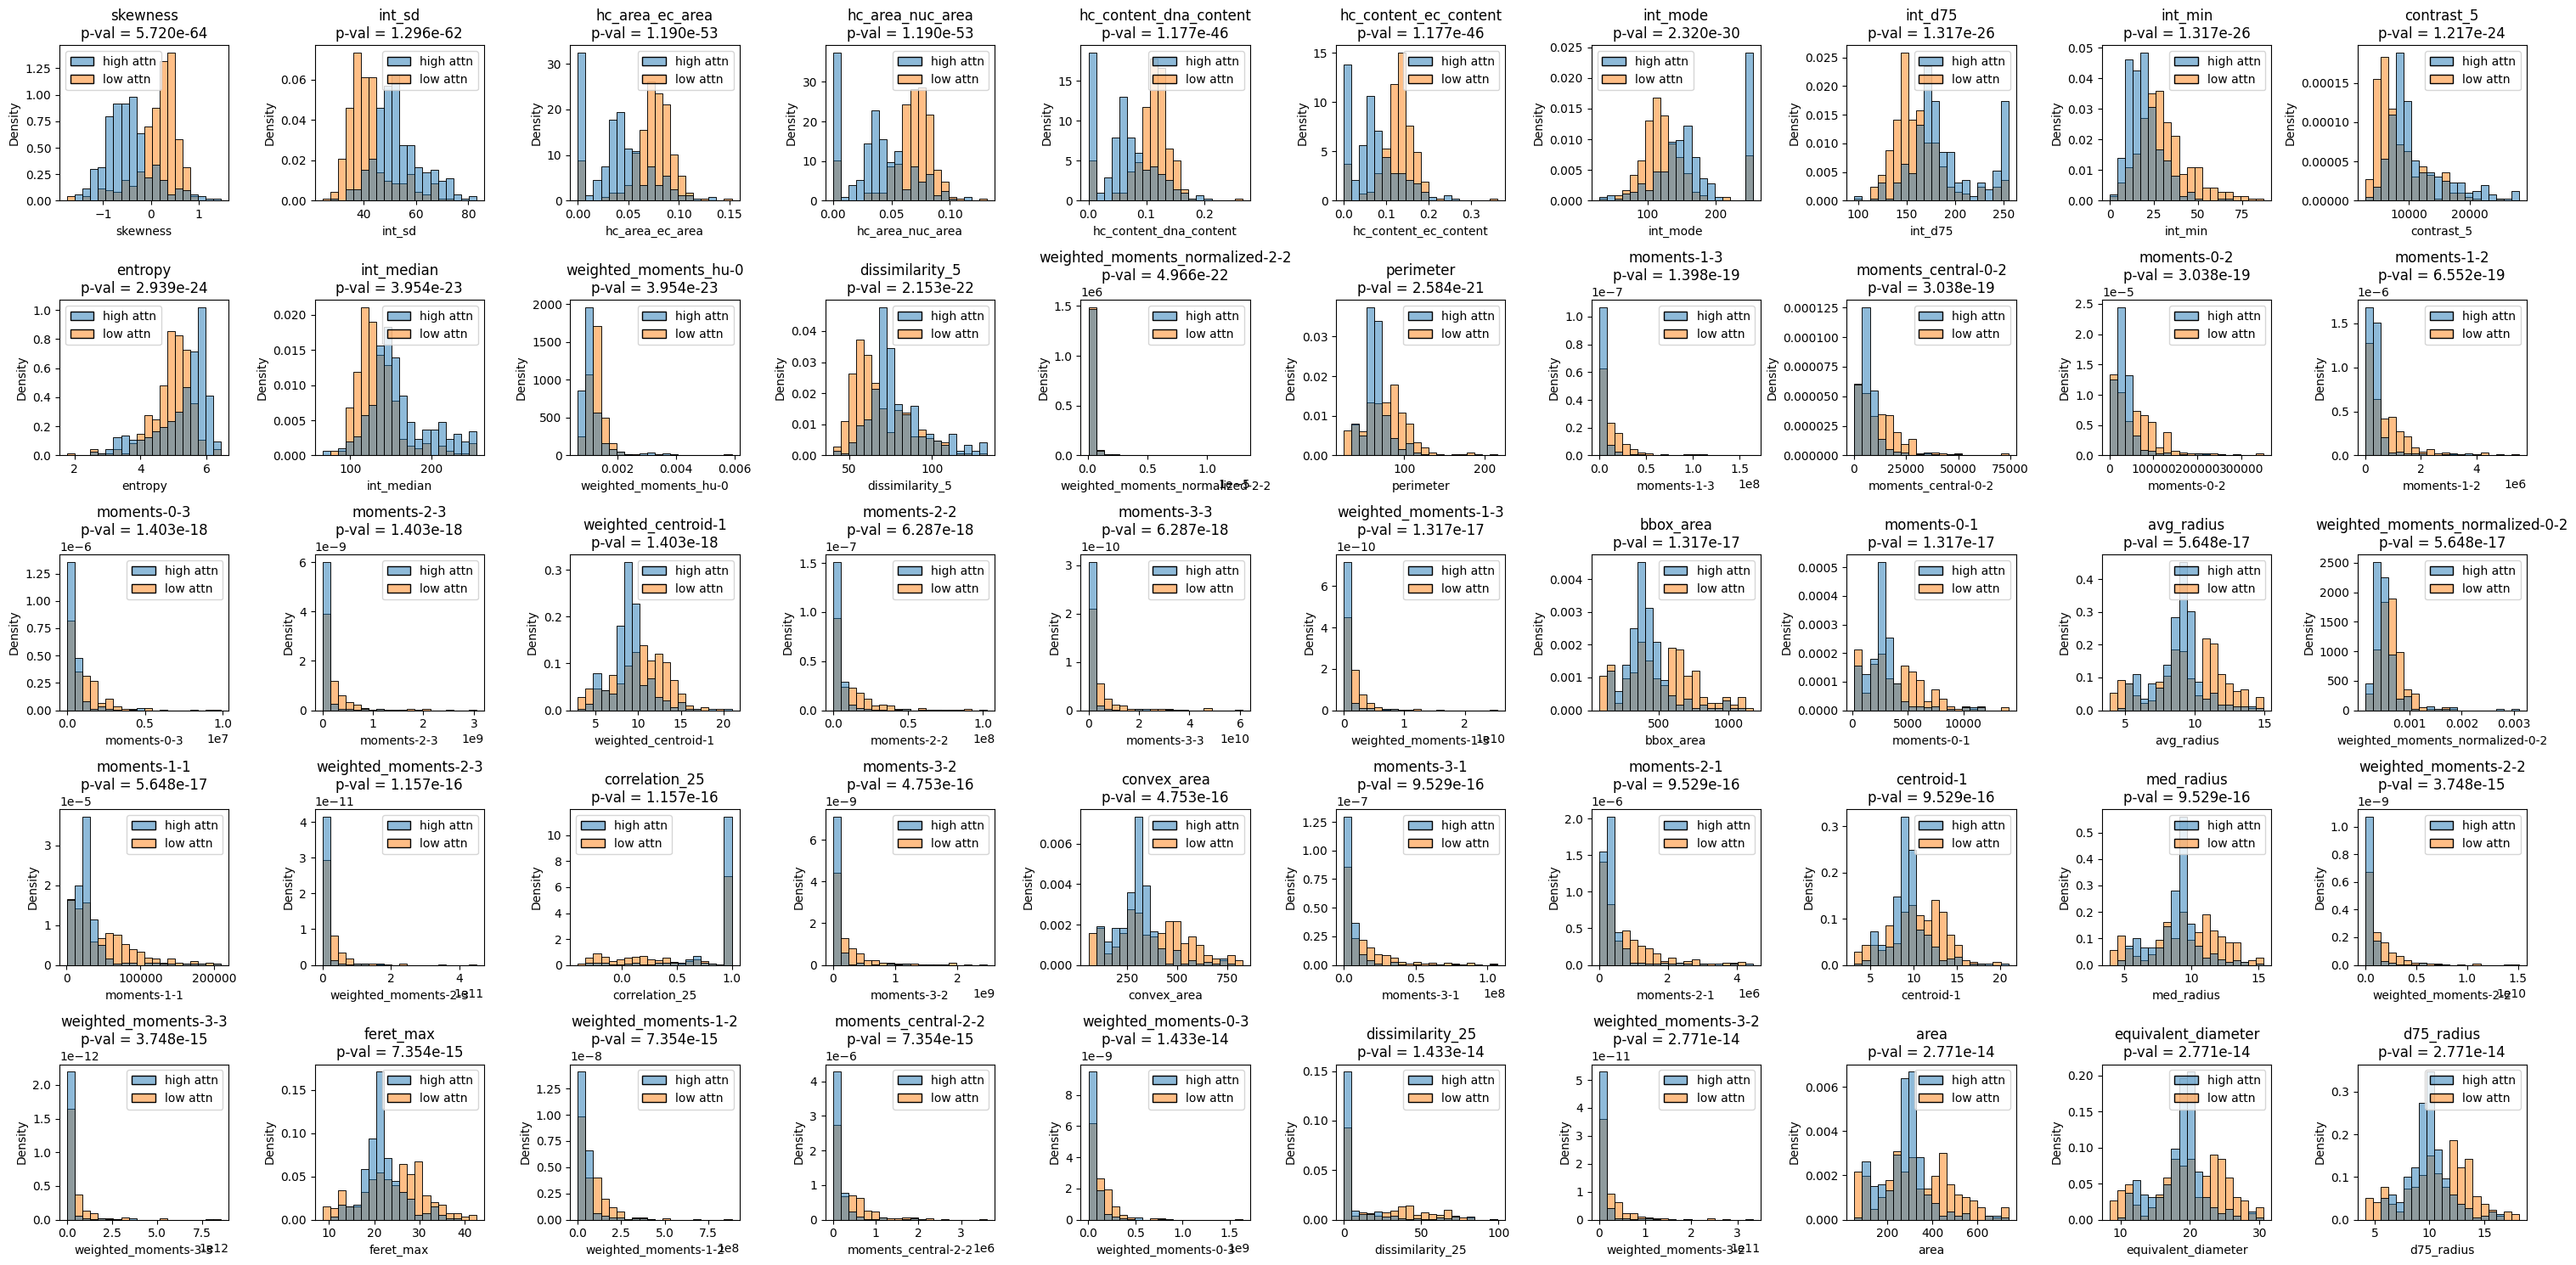

In [38]:
fig, axs = plt.subplots(5, 10, figsize=(30, 15))
for ax, col in zip(axs.flatten(), bot_cnt.sort_values('p-val (low)').index):
    sns.histplot(data=chrometrics.loc[np.concatenate((top_low_idx, bot_low_idx))], x=col, 
                 hue=['high attn'] * len(top_low_idx) + ['low attn'] * len(bot_low_idx) , ax=ax, bins=20, 
                 common_norm=False, stat='density')
    p = bot_cnt.loc[col, 'p-val (low)']
    ax.set_title(f'{col}\np-val = {p:0.3e}')
fig.tight_layout()

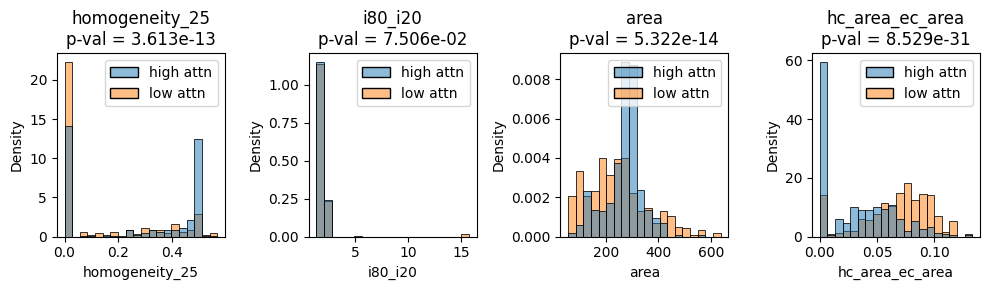

In [39]:
fig, axs = plt.subplots(1, 4, figsize=(10, 3))
for ax, col in zip(axs.flatten(), ['homogeneity_25', 'i80_i20', 'area', 'hc_area_ec_area']):
    sns.histplot(data=chrometrics.loc[np.concatenate((top_up_idx, bot_up_idx))], x=col, 
                 hue=['high attn'] * len(top_up_idx) + ['low attn'] * len(bot_up_idx) , ax=ax, bins=20, 
                 common_norm=False, stat='density')
    p = bot_cnt.loc[col, 'p-val (up)']
    ax.set_title(f'{col}\np-val = {p:0.3e}')
fig.tight_layout()

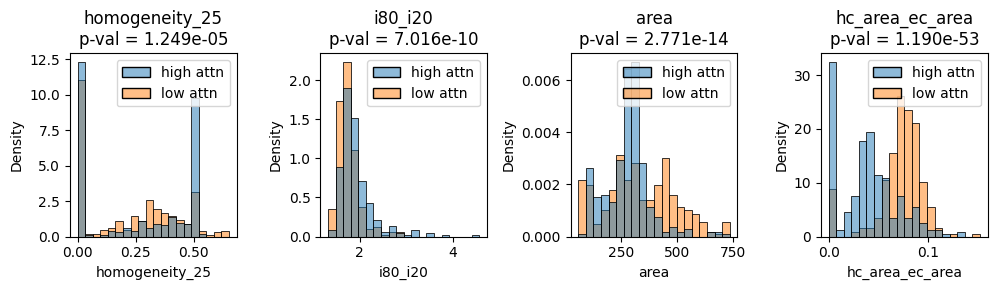

In [40]:
fig, axs = plt.subplots(1, 4, figsize=(10, 3))
for ax, col in zip(axs.flatten(), ['homogeneity_25', 'i80_i20', 'area', 'hc_area_ec_area']):
    sns.histplot(data=chrometrics.loc[np.concatenate((top_low_idx, bot_low_idx))], x=col, 
                 hue=['high attn'] * len(top_low_idx) + ['low attn'] * len(bot_low_idx) , ax=ax, bins=20, 
                 common_norm=False, stat='density')
    p = bot_cnt.loc[col, 'p-val (low)']
    ax.set_title(f'{col}\np-val = {p:0.3e}')
fig.tight_layout()

## Compare cluster proportions

### Fig. S4c

In [41]:
df = pd.read_csv('results/fig_2_umap_with_clusters.csv', index_col=0)

/tmp/ipykernel_2658651/544513941.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('results/fig_2_umap_with_clusters.csv', index_col=0)


In [42]:
traj = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_trajectory_classes.csv', index_col='patient')
dft = df.merge(traj, on='patient')
dft

,plate,well,series,cell,patient,time,qc,group,diagnosis,plate healthy,umap_x,umap_y,main group,cluster,trajectory
0,2,A02,0,40,P116,4,True,CNS-Glioma,cancer T1,NaN,NaN,NaN,NaN,NaN,up
1,2,A02,0,89,P116,4,True,CNS-Glioma,cancer T1,NaN,NaN,NaN,NaN,NaN,up
2,2,A02,0,90,P116,4,True,CNS-Glioma,cancer T1,NaN,NaN,NaN,NaN,NaN,up
3,2,A02,0,91,P116,4,True,CNS-Glioma,cancer T1,NaN,NaN,NaN,NaN,NaN,up
4,2,A02,0,106,P116,4,True,CNS-Glioma,cancer T1,NaN,NaN,NaN,NaN,NaN,up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867102,14,H12,9,450,P91,2,True,CNS-other,cancer T1,NaN,NaN,NaN,NaN,NaN,up
867103,14,H12,9,584,P91,2,True,CNS-other,cancer T1,NaN,NaN,NaN,NaN,NaN,up
867104,14,H12,9,601,P91,2,True,CNS-other,cancer T1,NaN,NaN,NaN,NaN,NaN,up
867105,14,H12,9,618,P91,2,True,CNS-other,cancer T1,NaN,NaN,NaN,NaN,NaN,up


Text(0.5, 1.0, 'Head & Neck plates only')

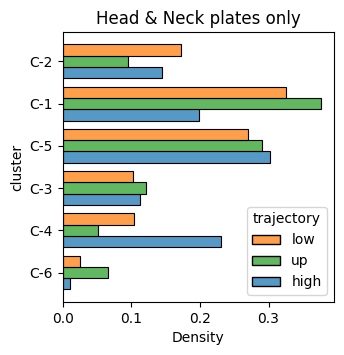

In [43]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax = sns.histplot(data=dft[dft['trajectory'].isin(['low', 'up', 'high']) & dft['plate'].astype(int).isin([3, 4, 5, 6])], 
                  y='cluster', hue='trajectory', common_norm=False, palette={'up' : '#2ca02c', 'low' : '#ff7f0e', 'high' : '#1f77b4'},
                  stat='density', discrete=True, multiple='dodge', shrink=.8, hue_order=['low', 'up', 'high'])
sns.move_legend(ax, 'lower right')
ax.set_title('Head & Neck plates only')

## MIL results

In [44]:
pat_diag_groups = pat_info.reset_index().groupby('group')['patient'].unique()
group = 'H&N cancer'
g_pats = p1ts[np.isin(p1ts, pat_diag_groups[group])]
g_pats

array(['P100', 'P107', 'P110', 'P114', 'P120', 'P130', 'P135', 'P14',
       'P142', 'P145', 'P148', 'P149', 'P18', 'P41', 'P55', 'P56', 'P63',
       'P67', 'P72', 'P77', 'P78', 'P79', 'P94', 'P98'], dtype=object)

In [45]:
import os
_cache = 'results/fig4_hn_mil_predictions.csv'
if os.path.exists(_cache):
    eval_df = pd.read_csv(_cache)
else:
    dfs = []

    for p in g_pats:
        name = f'3_6_traj_without_{p}'
        test_loader = test_up_vs_low_bagloader(use_groups=[group], use_patients=[p])
        df, _, _, _ = eval_model(name, test_loader) 
        dfs.append(df)
        print(p, (df['pred'] == df['lab']).mean())


    eval_df = pd.concat(dfs)
    eval_df.to_csv(_cache, index=False)
bag_df = eval_df.groupby(['pat', 'i'])[['pred', 'lab', 'group']].max()
bag_df['correct'] = bag_df['pred'] == bag_df['lab']
agg = bag_df.groupby(['pat', 'group'])['correct'].mean()
print(len(agg))
agg.reset_index()

24


,pat,group,correct
0,P100,up,0.636364
1,P107,low,1.000000
2,P110,low,0.000000
3,P114,up,0.727273
4,P120,up,0.000000
5,P130,up,0.000000
6,P135,up,0.818182
7,P14,low,1.000000
8,P142,up,0.000000
9,P145,low,1.000000


In [46]:
pat_df = bag_df.groupby(['pat', 'group'])['pred'].agg(lambda x : x.mode(dropna=True)[0]).dropna().reset_index()
pat_df.loc[pat_df['pred'] == 0, 'pred_group'] = 'low'
pat_df.loc[pat_df['pred'] == 1, 'pred_group'] = 'up'
pat_df['group'] = pd.Categorical(values=pat_df['group'], categories=['low', 'up'])
pat_df['pred_group'] = pd.Categorical(values=pat_df['pred_group'], categories=['low', 'up'])
pat_df.set_index(['pat', 'group'])

,,pred,pred_group
pat,group,,
P100,up,1.0,up
P107,low,0.0,low
P110,low,1.0,up
P114,up,1.0,up
P120,up,0.0,low
P130,up,0.0,low
P135,up,1.0,up
P14,low,0.0,low
P142,up,0.0,low


In [47]:
pat_df = pat_df.reset_index()
(pat_df['group'] == pat_df['pred_group']).mean()

np.float64(0.7083333333333334)

### Fig. 4f

In [48]:
import os

def cm_metrics_title(mat):
    """macro-F1 and balanced accuracy from a confusion matrix (rows=true, cols=pred)."""
    C = np.nan_to_num(np.asarray(mat.reindex(columns=list(mat.index)), dtype=float))
    tp = np.diag(C); row = C.sum(1); col = C.sum(0)
    with np.errstate(divide='ignore', invalid='ignore'):
        rec = np.where(row > 0, tp / row, np.nan)
        prec = np.where(col > 0, tp / col, np.nan)
        f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
    return 'mF1={:.2f}, BA={:.2f}'.format(
        np.nanmean(np.where(row > 0, f1, np.nan)), np.nanmean(rec))

/tmp/ipykernel_2658651/2414602138.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df.groupby(


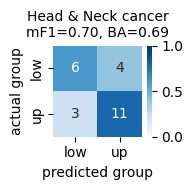

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
mat = pat_df.groupby(
    ['group', 'pred_group'])['pat'].count().reset_index().pivot(index='group', columns='pred_group', values='pat')
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cmap='Blues')
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
ax.set_title('Head & Neck cancer' + '\n' + cm_metrics_title(mat), fontsize=plt.rcParams['axes.labelsize'])
fig.tight_layout()

In [1]:
from scipy.stats import fisher_exact
res = fisher_exact([[6, 4], [3, 11]], alternative='greater')
res.pvalue

np.float64(0.06730380939561179)

### Fig. S4d

In [51]:
data = PlateDataset([2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], load_masks=True, strict_discard=False)


  0%|          | 0/14 [00:00<?, ?it/s]


  7%|▋         | 1/14 [00:00<00:06,  1.98it/s]


 14%|█▍        | 2/14 [00:00<00:03,  3.49it/s]


 21%|██▏       | 3/14 [00:00<00:02,  4.61it/s]


 29%|██▊       | 4/14 [00:01<00:03,  2.67it/s]

...


 79%|███████▊  | 11/14 [00:05<00:01,  2.19it/s]


 86%|████████▌ | 12/14 [00:05<00:01,  1.71it/s]


 93%|█████████▎| 13/14 [00:06<00:00,  1.55it/s]


100%|██████████| 14/14 [00:07<00:00,  1.49it/s]


100%|██████████| 14/14 [00:07<00:00,  1.87it/s]

In [52]:
traj = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_trajectory_classes.csv', index_col='patient')
groups = pd.read_csv('meta/patient_diagnosis_groups.csv').set_index('patient')

In [53]:
cdf = data.info.groupby(['patient', 'time'])['cell'].count().reset_index()
cdf = cdf[(cdf['cell'] > 100)]

p01s = cdf[(cdf['time'] == 1) | (cdf['time'] == 0)]['patient'].unique()
p01s

array(['H04', 'H05', 'H06', 'H07', 'H09', 'H10', 'H16', 'H18', 'H19',
       'H20', 'H22', 'H23', 'H25', 'H26', 'H29', 'H30', 'H31', 'H32',
       'H33', 'H36', 'H37', 'H39', 'H40', 'H43', 'H45', 'H47', 'H48',
       'H49', 'P100', 'P102', 'P104', 'P105', 'P106', 'P107', 'P109',
       'P110', 'P111', 'P112', 'P113', 'P114', 'P115', 'P116', 'P118',
       'P119', 'P12', 'P120', 'P123', 'P124', 'P125', 'P126', 'P127',
       'P128', 'P129', 'P13', 'P130', 'P131', 'P133', 'P134', 'P135',
       'P137', 'P138', 'P14', 'P142', 'P143', 'P144', 'P145', 'P147',
       'P148', 'P149', 'P15', 'P152', 'P154', 'P155', 'P156', 'P157',
       'P158', 'P16', 'P160', 'P161', 'P162', 'P163', 'P164', 'P165',
       'P166', 'P167', 'P17', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23',
       'P24', 'P25', 'P27', 'P28', 'P29', 'P30', 'P32', 'P33', 'P35',
       'P37', 'P38', 'P39', 'P41', 'P42', 'P43', 'P44', 'P48', 'P50',
       'P52', 'P53', 'P54', 'P55', 'P56', 'P58', 'P59', 'P60', 'P62',
       'P63', 'P6

In [54]:
p1ts = traj[traj['trajectory'].isin(['up', 'low'])].index.values
p1ts = p1ts[np.isin(p1ts, p01s)]
p1ts

array(['P100', 'P104', 'P105', 'P107', 'P109', 'P110', 'P111', 'P112',
       'P113', 'P114', 'P116', 'P118', 'P120', 'P123', 'P124', 'P127',
       'P128', 'P13', 'P130', 'P133', 'P135', 'P138', 'P14', 'P142',
       'P143', 'P145', 'P148', 'P149', 'P15', 'P156', 'P16', 'P162',
       'P164', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23', 'P25', 'P28',
       'P29', 'P30', 'P33', 'P38', 'P39', 'P41', 'P43', 'P48', 'P52',
       'P53', 'P55', 'P56', 'P59', 'P60', 'P62', 'P63', 'P64', 'P65',
       'P67', 'P69', 'P70', 'P72', 'P73', 'P75', 'P76', 'P77', 'P78',
       'P79', 'P80', 'P82', 'P83', 'P84', 'P87', 'P89', 'P90', 'P91',
       'P92', 'P94', 'P95', 'P96', 'P98', 'P99'], dtype=object)

In [55]:
groups['group'].loc['P104']

'CNS-Glioma'

In [56]:
import os
_cache = 'results/fig4_allcancers_mil_predictions.csv'
if os.path.exists(_cache):
    eval_df = pd.read_csv(_cache)
else:
    dfs = []

    for p in p1ts:
        name = f'2_14_traj_without_{p}'
        test_loader = test_up_vs_low_bagloader(use_patients=[p], use_groups=groups['group'].unique().tolist() + ['other'], 
                                               use_plates=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])
        df, _, _, _ = eval_model(name, test_loader) 
        dfs.append(df)
        print(p, (df['pred'] == df['lab']).mean())

    eval_df = pd.concat(dfs)
    eval_df.to_csv(_cache, index=False)
eval_df

,lab,pred,i,pat,group,attention 0,attention 1,attention 2,attention 3,attention 4,raw attention 0,raw attention 1,raw attention 2,raw attention 3,raw attention 4
0,1,1.0,0,P100,up,0.003290,0.003085,0.003171,0.003044,0.002875,-0.659399,-0.752650,-0.962705,-1.357798,-0.816045
1,1,1.0,0,P100,up,0.003034,0.002876,0.003068,0.003128,0.002720,-0.740280,-0.822802,-0.995649,-1.330598,-0.871483
2,1,1.0,0,P100,up,0.008782,0.009745,0.011167,0.012159,0.009683,0.322599,0.397390,0.296266,0.026970,0.398382
3,1,1.0,0,P100,up,0.012451,0.014642,0.018424,0.022953,0.015160,0.671645,0.804551,0.796946,0.662328,0.846733
4,1,1.0,0,P100,up,0.001474,0.001388,0.001462,0.001551,0.001279,-1.462056,-1.551387,-1.737226,-2.032495,-1.625778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45645,0,1.0,10,P99,low,0.017621,0.020004,0.013283,0.018744,0.008629,0.282813,0.299417,0.263874,0.545875,0.365364
45646,0,1.0,10,P99,low,0.001777,0.002259,0.001652,0.001401,0.001292,-2.011545,-1.881469,-1.820698,-2.047967,-1.533211
45647,0,1.0,10,P99,low,0.179745,0.146402,0.308580,0.038470,0.303823,2.605235,2.289833,3.409358,1.264863,3.926668
45648,0,1.0,10,P99,low,0.008661,0.013057,0.003985,0.025350,0.002416,-0.427486,-0.127203,-0.940070,0.847771,-0.907848


/tmp/ipykernel_2658651/91183936.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df.groupby(


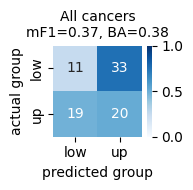

In [57]:
# rebuild bag_df from the all-cancers eval_df (cell above); the H&N bag_df from earlier must not carry over
bag_df = eval_df.groupby(['pat', 'i'])[['pred', 'lab', 'group']].max()
pat_df = bag_df.groupby(['pat', 'group'])['pred'].agg(lambda x : x.mode(dropna=True)[0]).reset_index().rename(columns={'group' : 'trajectory', 'pat' : 'patient'})
pat_df = pat_df.merge(groups.reset_index().rename(columns={'group' : 'diagnosis'}), on='patient', how='left')
pat_df['diagnosis'] = pat_df['diagnosis'].fillna('other')
pat_df.loc[pat_df['pred'] == 0, 'pred_trajectory'] = 'low'
pat_df.loc[pat_df['pred'] == 1, 'pred_trajectory'] = 'up'
pat_df['trajectory'] = pd.Categorical(values=pat_df['trajectory'], categories=['low', 'up'])
pat_df['pred_trajectory'] = pd.Categorical(values=pat_df['pred_trajectory'], categories=['low', 'up'])
pat_df['test correct'] = pat_df['trajectory'] == pat_df['pred_trajectory']
pat_df.set_index(['patient', 'trajectory'])


fig, ax = plt.subplots(1, 1, figsize=(2, 2))
mat = pat_df.groupby(
    ['trajectory', 'pred_trajectory'])['patient'].count().reset_index().pivot(index='trajectory', columns='pred_trajectory', values='patient')
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cmap='Blues')
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
ax.set_title('All cancers' + '\n' + cm_metrics_title(mat), fontsize=plt.rcParams['axes.labelsize'])
fig.tight_layout()

### Fig. S4e

/tmp/ipykernel_2658651/1026551079.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['diagnosis'] == 'H&N cancer'].groupby(


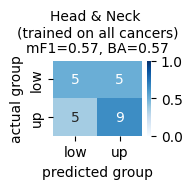

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
mat = pat_df[pat_df['diagnosis'] == 'H&N cancer'].groupby(
    ['trajectory', 'pred_trajectory'])['patient'].count().reset_index().pivot(index='trajectory', columns='pred_trajectory', values='patient')
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cmap='Blues')
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
ax.set_title('Head & Neck \n(trained on all cancers)' + '\n' + cm_metrics_title(mat), fontsize=plt.rcParams['axes.labelsize'])
fig.tight_layout()

### Fig. S4f

In [59]:
df1 = pd.DataFrame(pat_df.reset_index().groupby(['diagnosis', 'trajectory'])['test correct'].mean() * 100).rename(columns={'test correct': 'test correct %'}).round(decimals=2)
df2 = pd.DataFrame(pat_df.groupby(['diagnosis', 'trajectory'])['patient'].count()).rename(columns={'patient': '# patients'})
df1.merge(df2, left_index=True, right_index=True)

/tmp/ipykernel_2658651/1486983253.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1 = pd.DataFrame(pat_df.reset_index().groupby(['diagnosis', 'trajectory'])['test correct'].mean() * 100).rename(columns={'test correct': 'test correct %'}).round(decimals=2)
/tmp/ipykernel_2658651/1486983253.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2 = pd.DataFrame(pat_df.groupby(['diagnosis', 'trajectory'])['patient'].count()).rename(columns={'patient': '# patients'})


test correct %  # patients
diagnosis               trajectory                            
CNS-Ependymoma          low                  25.00           4
                        up                   50.00           2
CNS-Glioma              low                  42.86           7
                        up                    0.00           2
CNS-Medulloblastoma     low                   0.00           2
                        up                    0.00           1
CNS-Meningioma          low                   0.00           5
                        up                   16.67           6
CNS-other               low                   0.00           5
                        up                   66.67           6
Chordoma/Chondrosarcoma low                  12.50           8
                        up                   40.00           5
H&N cancer              low                  50.00          10
                        up                   64.29          14
Lymphoma                low                  33.33           3
                        up                     NaN           0
other                   low                    NaN           0
                        up                  100.00           3

## Baseline based on score

In [60]:
good_plates = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [61]:
groups = pd.read_csv('meta/patient_diagnosis_groups.csv').fillna('other')
traj = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_trajectory_classes.csv')
scores = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_scores.csv', index_col=0)
scores['score'] = scores['score'].clip(upper=1)  # cap similarity-to-healthy at 1; >1 arises from plate noise / small held-out healthy sample
pat_info = traj[traj['trajectory'].isin(['low', 'up'])].merge(groups, on='patient')
pat_info = pat_info.merge(scores[scores['time'] == 1], on='patient')
pat_info = pat_info[pat_info['plate'].isin(good_plates)].set_index('patient')
pat_info

,trajectory,group,time,pred H %,plate,score
patient,,,,,,
P100,up,H&N cancer,1,0.077381,3,0.094033
P104,low,CNS-Glioma,1,0.059490,2,0.073698
P105,low,CNS-Meningioma,1,0.185571,7,0.262559
P107,low,H&N cancer,1,0.451603,4,0.580520
P109,low,Lymphoma,1,0.370202,8,0.463846
...,...,...,...,...,...,...
P94,up,H&N cancer,1,0.098592,6,0.123482
P95,up,CNS-Ependymoma,1,0.111751,12,0.138851
P96,up,CNS-other,1,0.008467,13,0.010957


In [62]:
# more than for MIL as some patients have few cells but score was still computed
pats = pat_info[pat_info['group'] == 'H&N cancer'].index.values
len(pats), pats


(24,
 array(['P100', 'P107', 'P110', 'P114', 'P120', 'P130', 'P135', 'P14',
        'P142', 'P145', 'P148', 'P149', 'P18', 'P41', 'P55', 'P56', 'P63',
        'P67', 'P72', 'P77', 'P78', 'P79', 'P94', 'P98'], dtype=object))

0.17357634380284095


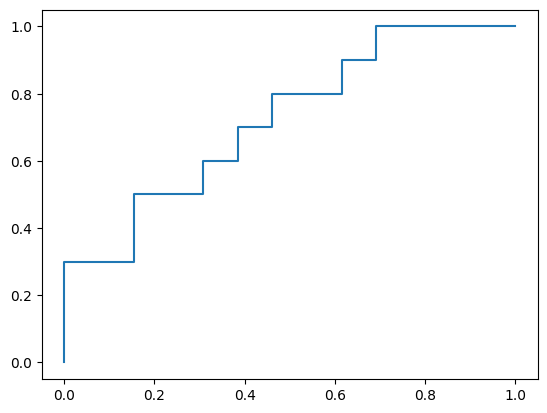

In [63]:
pat = 'P100'
other_pats = pats[pats != pat]
fpr, tpr, thresholds = roc_curve(pat_info.loc[other_pats, 'trajectory'].values == 'low', 
                                 pat_info.loc[other_pats, 'score'].values)
gmeans = np.sqrt(tpr * (1 - fpr))
thresh = thresholds[np.argmax(gmeans)]
scores = pat_info.loc[other_pats, 'score'].sort_values().values
ix = np.argwhere(scores == thresh)[0, 0]
if ix > 0:
  thresh = (scores[ix] + scores[ix - 1]) / 2  # put between class change
print(thresh)
plt.plot(fpr, tpr)

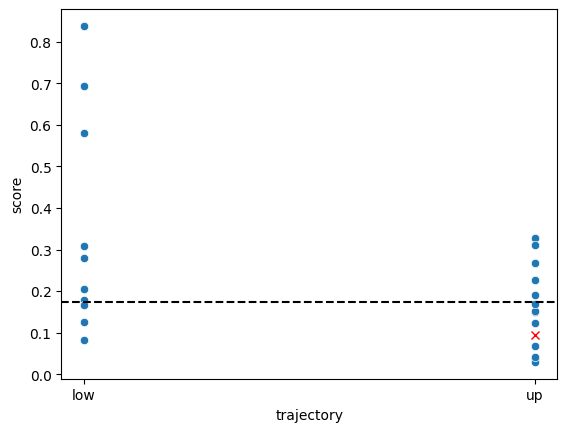

In [64]:
ax = sns.scatterplot(pat_info.loc[other_pats], x='trajectory', y='score')
ax.plot(pat_info.loc[pat, 'trajectory'], pat_info.loc[pat, 'score'], marker='x', color='red')
ax.axhline(thresh, ls='--', color='black')

In [65]:
pat_info.loc[pat, 'score'] >= thresh, pat_info.loc[pat, 'trajectory'] == 'low'

(np.False_, False)

#### Fig. S4g -- Head & Neck

In [66]:
res = []
for pat in pats:
    other_pats = pats[pats != pat]
    fpr, tpr, thresholds = roc_curve(pat_info.loc[other_pats, 'trajectory'].values == 'low', 
                                    pat_info.loc[other_pats, 'score'].values)
    gmeans = np.sqrt(tpr * (1 - fpr))
    thresh = thresholds[np.argmax(gmeans)]
    scores = pat_info.loc[other_pats, 'score'].sort_values().values
    ix = np.argwhere(scores == thresh)[0, 0]
    if ix > 0:
      thresh = (scores[ix] + scores[ix - 1]) / 2  # put between class change
    print(thresh)
    res.append((pat, pat_info.loc[pat, 'trajectory'], 'low' if pat_info.loc[pat, 'score'] >= thresh else 'up'))

pat_df = pd.DataFrame(res, columns=['patient', 'group', 'pred_group'])
pat_df

0.17357634380284095
0.15998968238491545
0.15998968238491545
0.17357634380284095
0.15998968238491545
0.15998968238491545
0.15998968238491545
0.15998968238491545
0.15998968238491545
0.15998968238491545
0.15998968238491545
0.15998968238491545
0.2726773928027838
0.15998968238491545
0.2726773928027838
0.17357634380284095
0.17357634380284095
0.15998968238491545
0.15998968238491545
0.17357634380284095
0.17357634380284095
0.17357634380284095
0.17357634380284095
0.17357634380284095


,patient,group,pred_group
0,P100,up,up
1,P107,low,low
2,P110,low,up
3,P114,up,up
4,P120,up,low
5,P130,up,low
6,P135,up,low
7,P14,low,low
8,P142,up,low
9,P145,low,low


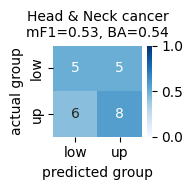

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
mat = pat_df.groupby(
    ['group', 'pred_group'])['patient'].count().reset_index().pivot(index='group', columns='pred_group', values='patient')
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cmap='Blues')
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
ax.set_title('Head & Neck cancer' + '\n' + cm_metrics_title(mat), fontsize=plt.rcParams['axes.labelsize'])
fig.tight_layout()

### Fig. S4h -- Plates 2-14 (greater/equal thresh for low)

In [68]:
pats = pat_info.index.values
len(pats), pats

(83,
 array(['P100', 'P104', 'P105', 'P107', 'P109', 'P110', 'P111', 'P112',
        'P113', 'P114', 'P116', 'P118', 'P120', 'P123', 'P124', 'P127',
        'P128', 'P13', 'P130', 'P133', 'P135', 'P138', 'P14', 'P142',
        'P143', 'P145', 'P148', 'P149', 'P15', 'P156', 'P16', 'P162',
        'P164', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23', 'P25', 'P28',
        'P29', 'P30', 'P33', 'P38', 'P39', 'P41', 'P43', 'P48', 'P52',
        'P53', 'P55', 'P56', 'P59', 'P60', 'P62', 'P63', 'P64', 'P65',
        'P67', 'P69', 'P70', 'P72', 'P73', 'P75', 'P76', 'P77', 'P78',
        'P79', 'P80', 'P82', 'P83', 'P84', 'P87', 'P89', 'P90', 'P91',
        'P92', 'P94', 'P95', 'P96', 'P98', 'P99'], dtype=object))

In [69]:
res = []
for pat in pats:
    other_pats = pats[pats != pat]
    fpr, tpr, thresholds = roc_curve(pat_info.loc[other_pats, 'trajectory'].values == 'low', 
                                    pat_info.loc[other_pats, 'score'].values)
    gmeans = np.sqrt(tpr * (1 - fpr))
    thresh = thresholds[np.argmax(gmeans)]
    scores = pat_info.loc[other_pats, 'score'].sort_values().values
    ix = np.argwhere(scores == thresh)[0, 0]
    if ix > 0:
      thresh = (scores[ix] + scores[ix - 1]) / 2  # put between class change
    print(thresh)
    res.append((pat, pat_info.loc[pat, 'trajectory'], 'low' if pat_info.loc[pat, 'score'] >= thresh else 'up'))

pat_df = pd.DataFrame(res, columns=['patient', 'group', 'pred_group'])
pat_df

0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.13893610272165724
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.18974324302800416
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.19786271184209345
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.15791011035144303
0.18974324302800416


,patient,group,pred_group
0,P100,up,up
1,P104,low,up
2,P105,low,low
3,P107,low,low
4,P109,low,low
...,...,...,...
78,P94,up,up
79,P95,up,up
80,P96,up,up
81,P98,up,up


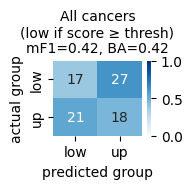

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
mat = pat_df.groupby(
    ['group', 'pred_group'])['patient'].count().reset_index().pivot(index='group', columns='pred_group', values='patient')
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cmap='Blues')
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
ax.set_title('All cancers\n(low if score ≥ thresh)' + '\n' + cm_metrics_title(mat), fontsize=plt.rcParams['axes.labelsize'])
fig.tight_layout()

### Fig. S4i -- Plates 2-14 (greater/equal thresh for up)

In [71]:
pats = pat_info.index.values
len(pats), pats

(83,
 array(['P100', 'P104', 'P105', 'P107', 'P109', 'P110', 'P111', 'P112',
        'P113', 'P114', 'P116', 'P118', 'P120', 'P123', 'P124', 'P127',
        'P128', 'P13', 'P130', 'P133', 'P135', 'P138', 'P14', 'P142',
        'P143', 'P145', 'P148', 'P149', 'P15', 'P156', 'P16', 'P162',
        'P164', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23', 'P25', 'P28',
        'P29', 'P30', 'P33', 'P38', 'P39', 'P41', 'P43', 'P48', 'P52',
        'P53', 'P55', 'P56', 'P59', 'P60', 'P62', 'P63', 'P64', 'P65',
        'P67', 'P69', 'P70', 'P72', 'P73', 'P75', 'P76', 'P77', 'P78',
        'P79', 'P80', 'P82', 'P83', 'P84', 'P87', 'P89', 'P90', 'P91',
        'P92', 'P94', 'P95', 'P96', 'P98', 'P99'], dtype=object))

In [72]:
res = []
for pat in pats:
    other_pats = pats[pats != pat]
    fpr, tpr, thresholds = roc_curve(pat_info.loc[other_pats, 'trajectory'].values == 'up', 
                                    pat_info.loc[other_pats, 'score'].values)
    gmeans = np.sqrt(tpr * (1 - fpr))
    thresh = thresholds[np.argmax(gmeans)]
    scores = pat_info.loc[other_pats, 'score'].sort_values().values
    ix = np.argwhere(scores == thresh)[0, 0]
    if ix > 0:
      thresh = (scores[ix] + scores[ix - 1]) / 2  # put between class change
    print(thresh)
    res.append((pat, pat_info.loc[pat, 'trajectory'], 'up' if pat_info.loc[pat, 'score'] >= thresh else 'low'))

pat_df = pd.DataFrame(res, columns=['patient', 'group', 'pred_group'])
pat_df

0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103


0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.10105829236587754
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0980801361373224
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.0986746176744103
0.098674617

,patient,group,pred_group
0,P100,up,low
1,P104,low,low
2,P105,low,up
3,P107,low,up
4,P109,low,up
...,...,...,...
78,P94,up,up
79,P95,up,up
80,P96,up,low
81,P98,up,low


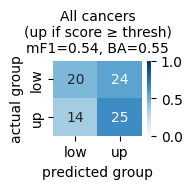

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
mat = pat_df.groupby(
    ['group', 'pred_group'])['patient'].count().reset_index().pivot(index='group', columns='pred_group', values='patient')
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cmap='Blues')
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
ax.set_title('All cancers\n(up if score ≥ thresh)' + '\n' + cm_metrics_title(mat), fontsize=plt.rcParams['axes.labelsize'])
fig.tight_layout()